# Cross-sectional analysis of returns on the NASDAQ-100: a rolling comparison of LSTM, GRU and Random Forest

## Phase 0: Task Definition and Choice of Dataset

### Introduction
In this project, we have sought to apply a methodology previously validated by Thomas Fischer & Christopher Krauss in their paper *Deep learning with long short-term memory networks for financial market predictions* to test the effectiveness of LSTM networks in forecasting financial markets on a large scale using ‘recent’ datasets.

In their work, Fischer & Krauss applied an LSTM architecture – known for its ability to learn sequences – to predict directional movements (whether tomorrow’s price will rise or fall relative to the median) of the constituent shares of the S&P 500 index. The authors highlight significant success when compared to *memory-free* models (such as Random Forest or the Logistic Regression classifier), although performance varied over time. By using the LSTM network’s forecasts to identify S&P 500 stocks that would, over time, outperform or underperform the average, and by implementing a strategy known as *long-short* (which we will describe in more detail later), they managed to achieve significant daily returns (daily returns of 0.46% and a Sharpe ratio of 5.8 before transaction costs), although these eroded over time. Whilst the outperformance relative to the market was very clear between 1992 and 2009, from 2010 onwards the excess returns appear to have been eliminated by arbitrage, with returns fluctuating around zero after taking transaction costs into account. Whilst between 1992 and 2009 the LSTM model managed to significantly outperform the market, from 2010 onwards its competitive advantage appears to have been nullified. The authors hypothesise that this is due to the growing prevalence of similar strategies amongst industry professionals, which has led to the exploitation and elimination of the market inefficiencies that the LSTM was previously able to capitalise on. The market would appear to have become more efficient than the *machine learning* methods used.

### Project Objective
Using a methodology similar to that of Fischer & Krauss, we focused on a more recent dataset and a different index (the NASDAQ-100), with the aim of verifying whether the LSTM architecture retains its predictive power during a period of greater market efficiency (post-2010).

The dataset under consideration comprises return data for all individual securities that have been part of the NASDAQ 100 index from 2008 to the present (July 2026).

### In Brief

1. Task: This is a binary classification problem. The objective is to predict whether the return on a ticker on a given day will be above or below the daily cross-sectional median of the returns of all tickers in the dataset.

2. Median used for normalisation: The median used is the daily cross-sectional median of returns. This means that, for each day, the median of the returns for all valid tickers on that day is calculated.

3. Target to be predicted: The target that the LSTM must predict is a binary label for each ticker and day:
    - 1 if the ticker’s return on the following day ( $r_{t+1}$ ) will be greater than or equal to the daily median ( $r^{median}_{t+1}$ ).
    - 0 otherwise.
The label is therefore shifted forward by one day to predict the return for the following day.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import matplotlib as mpl

import warnings
warnings.filterwarnings('ignore')

from scipy.stats import kurtosis, skew
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from hyperopt import hp, tpe, Trials, STATUS_OK
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, GRU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import RMSprop, Adam
from pathlib import Path
from datetime import datetime

In [19]:
plt.style.use('default')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

color1=plt.cm.plasma(0.2)
color2=plt.cm.plasma(0.4)

## Phase 1: Acquisition and Data Cleaning

### Considerations regarding the shares under consideration

The NASDAQ-100 is a share index comprising the 100 largest non-financial companies listed on the NASDAQ stock exchange. It is a weighted index; the weighting of the various constituent companies is based on their market capitalisation, with certain rules in place to account for the influence of the largest constituents. It excludes financial companies and includes some foreign companies. These two factors distinguish it from the S&P 500 index.

Given that it comprises the ‘top 100 companies’ of the moment, this is an index whose constituent companies are dynamic (the individual constituents change over time). The file ‘NASDAQ100_between_2008_2026.csv’ contains all the *tickers* for the shares that were part of the NASDAQ 100 index during the period 2008–2026. The dataset includes both securities that were part of the index for the entire period under consideration, as well as those that left or joined the index at a certain point in time. The decision to also include securities that left the index was made to avoid **survivorship bias**, the error of considering only those companies that survived until the end of the study period.

Per ciascun *ticker* abbiamo acquisito attraverso la libreria **yfinance** di Python i valori giornalieri dell'indicatore **'Adj Close'** (prezzo di chiusura aggiustato) che mostra il valore reale di un'azione. Tiene conto di eventi come dividendi e frazionamenti ed è quindi più utile per il calcolo del rendimento totale giornaliero $r_t$ percentuale di un singolo titolo, che è stata proprio la feature che abbiamo considerato
$$ r_t = \frac{Adj\_close(t) - Adj\_close(t-1)}{Adj\_close(t-1)} = \frac{Adj\_close(t)}{Adj\_close(t-1)} - 1 $$

### Limitations
We do not have a precise timestamp for the dates on which each ticker was added to or removed from the NASDAQ-100. For this reason, we have defined the **static** universe as ‘all tickers that were part of the index between 2008 and 2026’ and then applied the filter for sufficiently long sequences.
This approach introduces two possible deviations from a ‘real’ backtest:
1. In some periods, we may include securities that were not actually in the index;
2. In others, we do not include securities that were in fact included (but do not have a sufficient number of years’ worth of data).

As an extension, in future we could reconstruct the historical composition of the index (e.g. using official Nasdaq filings or commercial databases) and update the universe on a day-by-day basis.

### Initial Data Cleaning
We check the maximum length of each ‘consecutive data block’ for each ticker, requiring a length of 1,000 days or more – which we will subsequently define as the study period – ensuring that every selected ticker can appear in at least one complete training/test window.

In [7]:
# ==== PARAMETRI ====
start_date = "2008-01-02"
end_date   = "2026-07-13"

tickers = pd.read_csv(f"NASDAQ100_between_2008_2026.csv")
ticker_list = tickers['ticker'].to_list()
df = yf.download(ticker_list, start=start_date, end=end_date, auto_adjust=False, progress=True)

[****                   8%                       ]  22 of 275 completed$ALXN: possibly delisted; no timezone found
[*****                 11%                       ]  29 of 275 completed$DISCA: possibly delisted; no timezone found
[******                12%                       ]  33 of 275 completed$NUAN: possibly delisted; no timezone found
[******                12%                       ]  34 of 275 completed$XLNX: possibly delisted; no timezone found
[******                13%                       ]  36 of 275 completed$DTV: possibly delisted; no timezone found
[********              16%                       ]  44 of 275 completed$FI: possibly delisted; no timezone found
[********              17%                       ]  46 of 275 completed$GMCR: possibly delisted; no price data found  (1d 2008-01-02 -> 2026-07-13)
[*********             19%                       ]  51 of 275 completed$CTXS: possibly delisted; no timezone found
[*********             19%                       

In [8]:
# Pulizia dataset

# 1. Identificazione dei livelli del MultiIndex
price_levels = df.columns.get_level_values(0).unique()   # Adj Close, Open, High, ...
tickers = df.columns.get_level_values(1).unique()

# 2. Funzione per calcolare la lunghezza massima di una run consecutiva
def max_consecutive_run(series):
    """
    Calcola la lunghezza massima di una sequenza consecutiva di valori non NaN.
    """
    return series.notna().astype(int).groupby(series.notna().astype(int).diff().ne(0).cumsum()).cumsum().max()

# 3. Filtro tickers con run consecutiva > 1000 giorni (corrisponde a uno study period)
min_run_length = 1000
good_tickers = []

for t in tickers:
    # Seleziona la serie 'Adj Close' per il ticker
    adj_close_series = df[('Adj Close', t)]
    
    # Calcola la lunghezza massima della run consecutiva
    max_run = max_consecutive_run(adj_close_series)
    
    if max_run >= min_run_length:
        good_tickers.append(t)

print(f"Valid tickers: {len(good_tickers)} over {len(tickers)}")

# 4. Mantengo solo i tickers buoni (tutte le loro colonne Price)
df = df.loc[:, df.columns.get_level_values(1).isin(good_tickers)]

# (opzionale) Riordina le colonne per ticker
df = df.sort_index(axis=1, level=[1, 0])

Valid tickers: 194 over 275


### Display of Daily Returns

Below, we present an overall view, covering the entire period under consideration (2008–2026), of the logarithmic trend in the average and median daily returns of the 196 securities under consideration, together with the respective distribution of median returns.

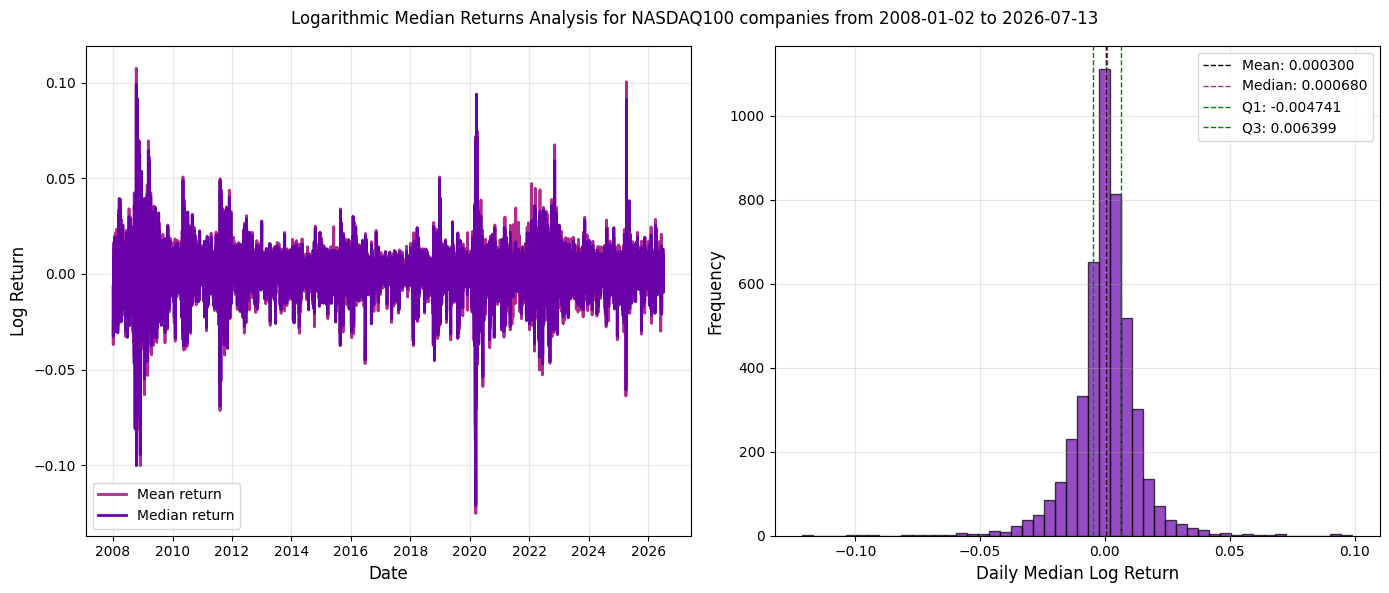

Statistics of logarithmic daily median returns:
Mean of daily median returns: 0.000300
Median of daily median returns: 0.000680
Standard deviation of daily median returns: 0.013027
Skewness of daily median returns: -0.448280
Kurtosis of daily median returns: 9.437842


In [12]:
# Prima analisi delle distribuzioni con il log_return

# Media e la mediana giornaliera di Adj Close
adj_close = df['Adj Close'].copy()  # Seleziona solo le colonne 'Adj Close'

log_returns = np.log(adj_close / adj_close.shift(1))
log_returns = log_returns.dropna(how='all')  # Rimuove eventuali NaN

daily_mean = log_returns.mean(axis=1)       # Ritorno medio giornaliero 
daily_median = log_returns.median(axis=1)   # Mediana giornaliera 
daily_mean = daily_mean.dropna()
daily_median = daily_median.dropna()

# Crea il multiplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Line plot: Media e mediana giornaliera di Adj Close
axes[0].plot(daily_mean.index, daily_mean, label='Mean return', color=color2)
axes[0].plot(daily_median.index, daily_median, label='Median return', color=color1)
#axes[0].set_title('Daily Mean and Median Return', fontsize=14)
axes[0].set_ylabel('Log Return', fontsize=12)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Istogramma: Distribuzione dei ritorni
axes[1].hist(daily_median, bins=50, color=color1, alpha=0.7, edgecolor='black')
axes[1].axvline(daily_median.mean(), color='black', linestyle='dashed', linewidth=1, label=f'Mean: {daily_median.mean():.6f}')
axes[1].axvline(daily_median.median(), color=color2, linestyle='dashed', linewidth=1, label=f'Median: {daily_median.median():.6f}')
axes[1].axvline(daily_median.quantile(0.25), color='green', linestyle='dashed', linewidth=1, label=f'Q1: {daily_median.quantile(0.25):.6f}')
axes[1].axvline(daily_median.quantile(0.75), color='green', linestyle='dashed', linewidth=1, label=f'Q3: {daily_median.quantile(0.75):.6f}')
#axes[1].set_title(f'Distribution of Daily Average Return between {start_date} & {end_date}', fontsize=12)
axes[1].set_xlabel('Daily Median Log Return', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Migliora il layout
plt.suptitle(f'Logarithmic Median Returns Analysis for NASDAQ100 companies from {start_date} to {end_date}')
plt.tight_layout()
plt.show()

# Statistica
print("Statistics of logarithmic daily median returns:")
print(f"Mean of daily median returns: {daily_median.mean():.6f}")
print(f"Median of daily median returns: {daily_median.median():.6f}")
print(f"Standard deviation of daily median returns: {daily_median.std():.6f}")
print(f"Skewness of daily median returns: {daily_median.skew():.6f}")
print(f"Kurtosis of daily median returns: {daily_median.kurtosis():.6f}")

- Skewness: measures the asymmetry of a distribution relative to the mean. The fact that the median is higher than the mean confirms a negative skewness ($\simeq 0.45$). The distribution is more skewed towards a negative average return on securities. There are a few days of very severe market downturns that drag the mean below the median.

- Kurtosis: measures the shape of the tails relative to a normal distribution (how concentrated the data are around the centre). Kurtosis > 0 (leptocurtic) indicates heavy tails. A value of $9.4$ is quite high: extreme outliers occur more frequently than would be expected from a Gaussian distribution.

- A volatility of $\simeq 30\%$ (median market volatility) indicates significant volatility during turbulent periods.

### Analysis on Different Time Periods

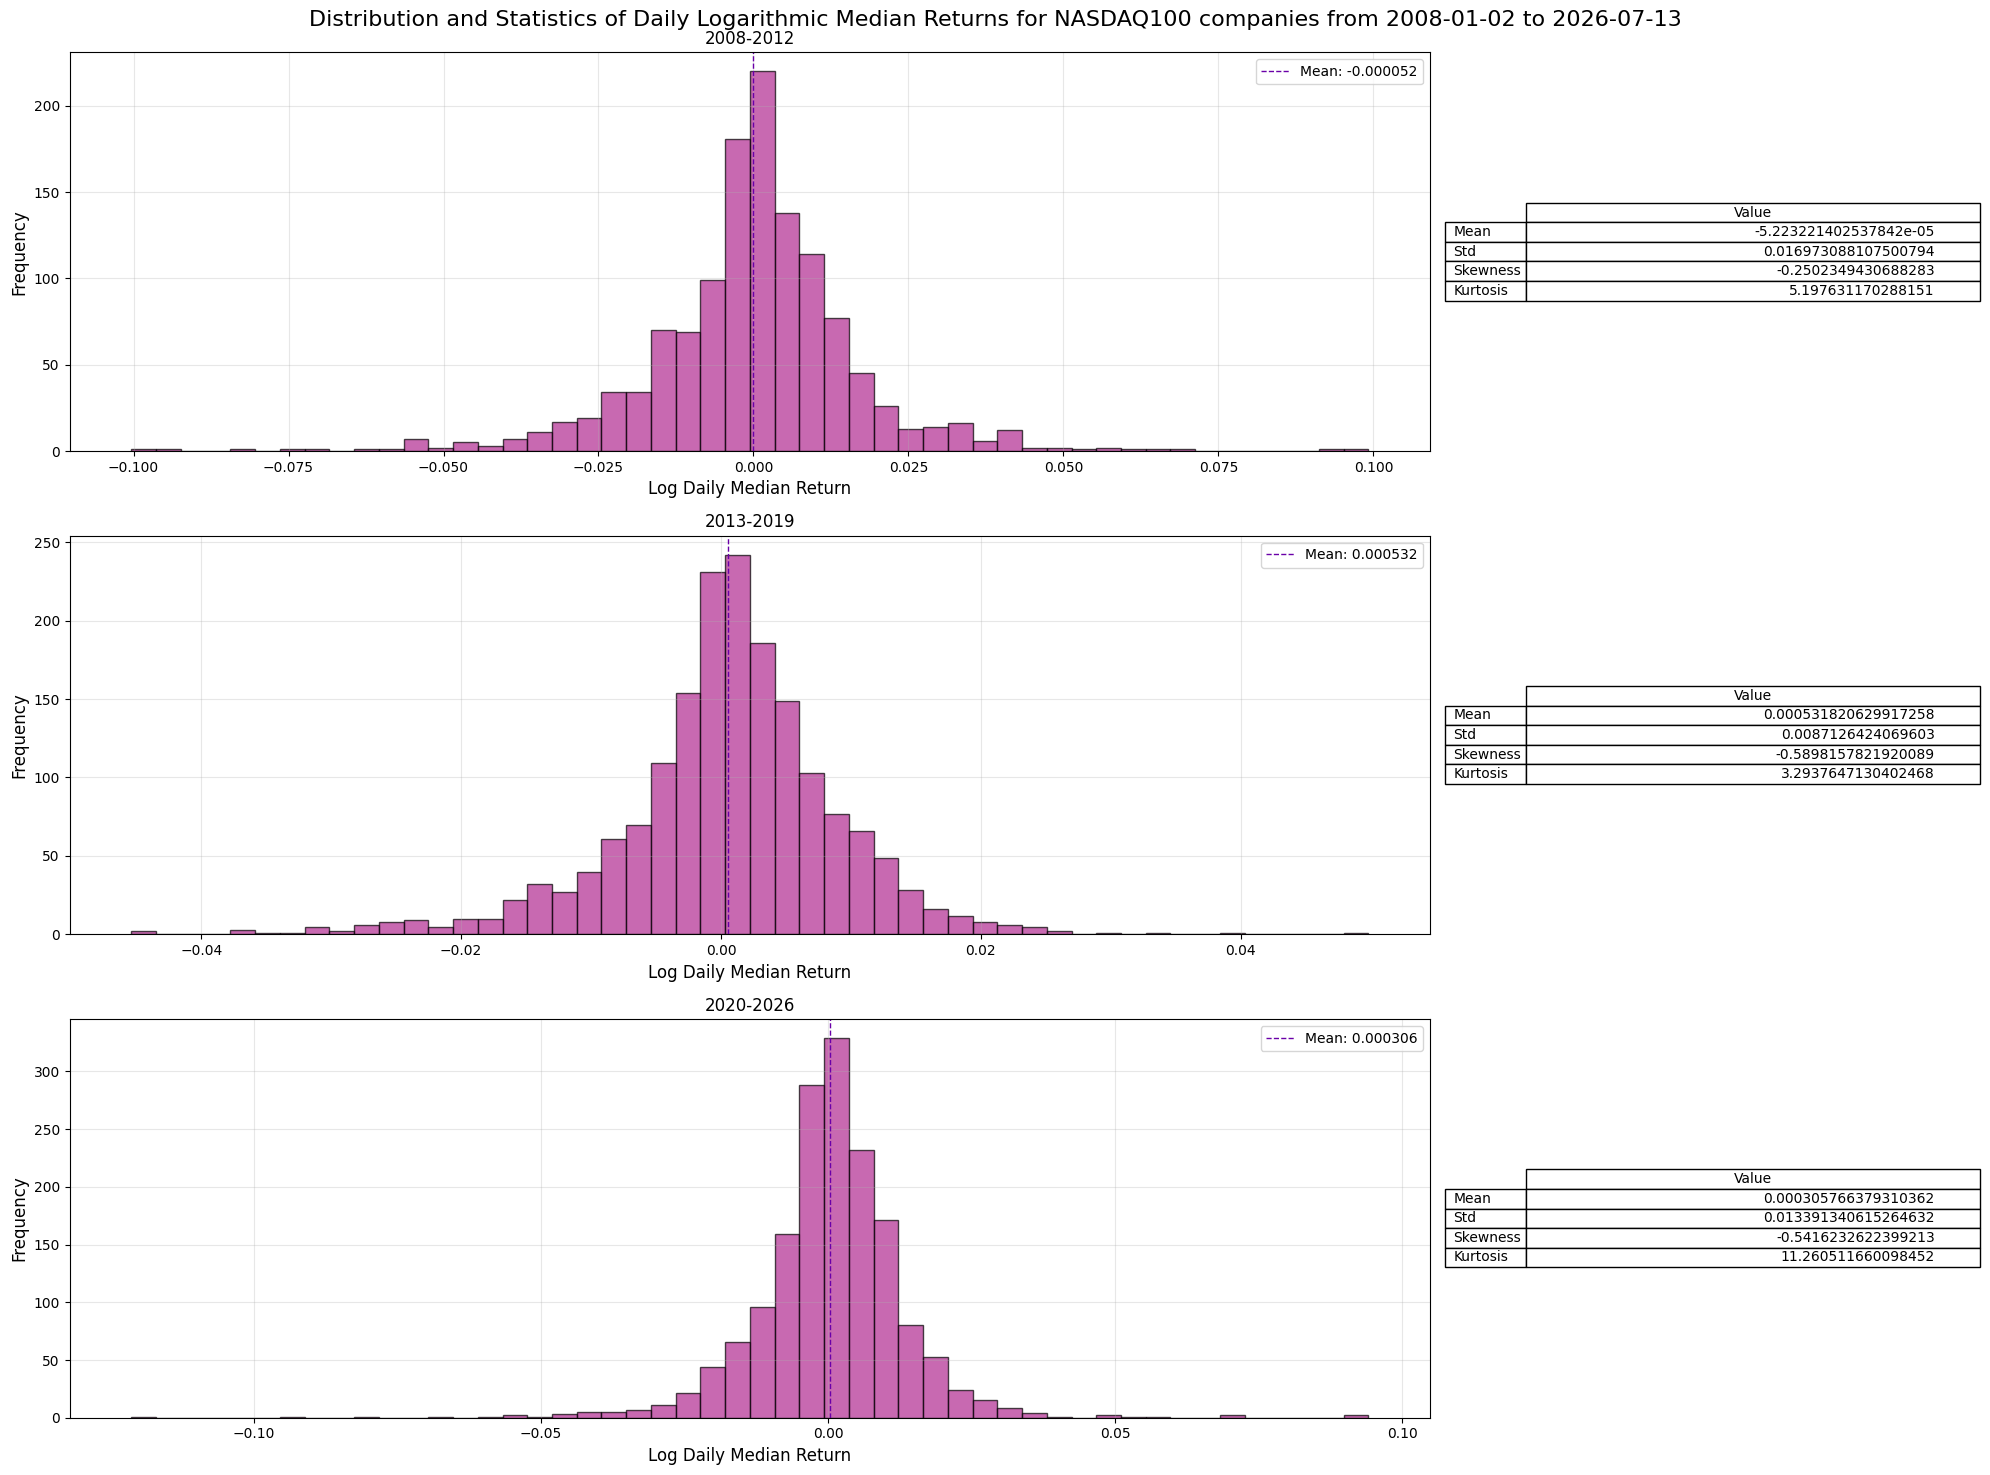

In [14]:
# Suddivisione in fasce temporali
daily_median.index = pd.to_datetime(daily_median.index, errors='coerce')
daily_median = daily_median.dropna()

daily_median_2008_2012 = daily_median.loc['2008-01-03':'2012-12-31']
daily_median_2013_2019 = daily_median.loc['2013-01-03':'2019-12-31']
daily_median_2020_2026 = daily_median.loc['2020-01-01':'2026-07-13']

# Calcolo delle statistiche per ogni fascia temporale
stats_2008_2012 = {
    'Mean': daily_median_2008_2012.mean(),
    'Std': daily_median_2008_2012.std(),
    'Skewness': daily_median_2008_2012.skew(),
    'Kurtosis': daily_median_2008_2012.kurtosis()
}

stats_2013_2019 = {
    'Mean': daily_median_2013_2019.mean(),
    'Std': daily_median_2013_2019.std(),
    'Skewness': daily_median_2013_2019.skew(),
    'Kurtosis': daily_median_2013_2019.kurtosis()
}

stats_2020_2026 = {
    'Mean': daily_median_2020_2026.mean(),
    'Std': daily_median_2020_2026.std(),
    'Skewness': daily_median_2020_2026.skew(),
    'Kurtosis': daily_median_2020_2026.kurtosis()
}

# Crea il multiplot
fig, axes = plt.subplots(3, 2, figsize=(20, 15), gridspec_kw={'width_ratios': [3, 1]})

# 1. Prima fascia: 2008-2012
axes[0, 0].hist(daily_median_2008_2012, bins=50, color=color2, alpha=0.7, edgecolor='black')
axes[0, 0].axvline(stats_2008_2012['Mean'], color=color1, linestyle='dashed', linewidth=1, label=f"Mean: {stats_2008_2012['Mean']:.6f}")
axes[0, 0].set_title('2008-2012', fontsize=12)
axes[0, 0].set_xlabel('Log Daily Median Return')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# Tabella per 2008-2012
axes[0, 1].axis('tight')
axes[0, 1].axis('off')
table_2008_2012 = pd.DataFrame(stats_2008_2012, index=['Value']).T
axes[0, 1].table(cellText=table_2008_2012.values, colLabels=table_2008_2012.columns, rowLabels=table_2008_2012.index, loc='center')

# 2. Seconda fascia: 2013-2019
axes[1, 0].hist(daily_median_2013_2019, bins=50, color=color2, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(stats_2013_2019['Mean'], color=color1, linestyle='dashed', linewidth=1, label=f"Mean: {stats_2013_2019['Mean']:.6f}")
axes[1, 0].set_title('2013-2019', fontsize=12)
axes[1, 0].set_xlabel('Log Daily Median Return')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# Tabella per 2013-2019
axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table_2013_2019 = pd.DataFrame(stats_2013_2019, index=['Value']).T
axes[1, 1].table(cellText=table_2013_2019.values, colLabels=table_2013_2019.columns, rowLabels=table_2013_2019.index, loc='center')

# 3. Terza fascia: 2020-2026
axes[2, 0].hist(daily_median_2020_2026, bins=50, color=color2, alpha=0.7, edgecolor='black')
axes[2, 0].axvline(stats_2020_2026['Mean'], color=color1, linestyle='dashed', linewidth=1, label=f"Mean: {stats_2020_2026['Mean']:.6f}")
axes[2, 0].set_title('2020-2026', fontsize=12)
axes[2, 0].set_xlabel('Log Daily Median Return')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].grid(alpha=0.3)
axes[2, 0].legend()

# Tabella per 2020-2026
axes[2, 1].axis('tight')
axes[2, 1].axis('off')
table_2020_2026 = pd.DataFrame(stats_2020_2026, index=['Value']).T
axes[2, 1].table(cellText=table_2020_2026.values, colLabels=table_2020_2026.columns, rowLabels=table_2020_2026.index, loc='center')

# Migliora il layout
plt.suptitle(f'Distribution and Statistics of Daily Logarithmic Median Returns for NASDAQ100 companies from {start_date} to {end_date}', fontsize=16)
plt.tight_layout()
plt.show()

- 2008–2012: This period includes the euro crisis (2009). Slightly negative mean ($\simeq 0.005 \%$). High standard deviation ($\simeq 1.7 \%$). Moderate skewness ($\simeq -0.25$) Heavy tails are observed (kurtosis $\simeq 5.2$) but not as extreme as those seen around 2020.

- 2013–2019: Positive mean ($\simeq 0.003 \%$). Lower standard deviation ($\simeq 0.87 \%$). More negative skew ($-0.59$). Lower kurtosis ($\simeq 3.3$) (“almost” Gaussian).

- 2020–2026: Moderately positive mean ($\simeq 0.03\%$). Standard deviation rises ($\simeq 1.3\%$). Skew ($\simeq –0.54$). Very high kurtosis ($\simeq 11.3$). This is likely due to the impact of the 2020 COVID-19 pandemic and the subsequent crisis (extremely heavy tails).

Overall

– Volatility and the tails (kurtosis) fluctuate significantly in response to major events: we expect the LSTM to have to adapt to different regimes.

– The average sign of returns shifts from negative (the 2008 crisis) to positive (2013–2019), then remains unstable.

### Rolling Statistics (252-day window)

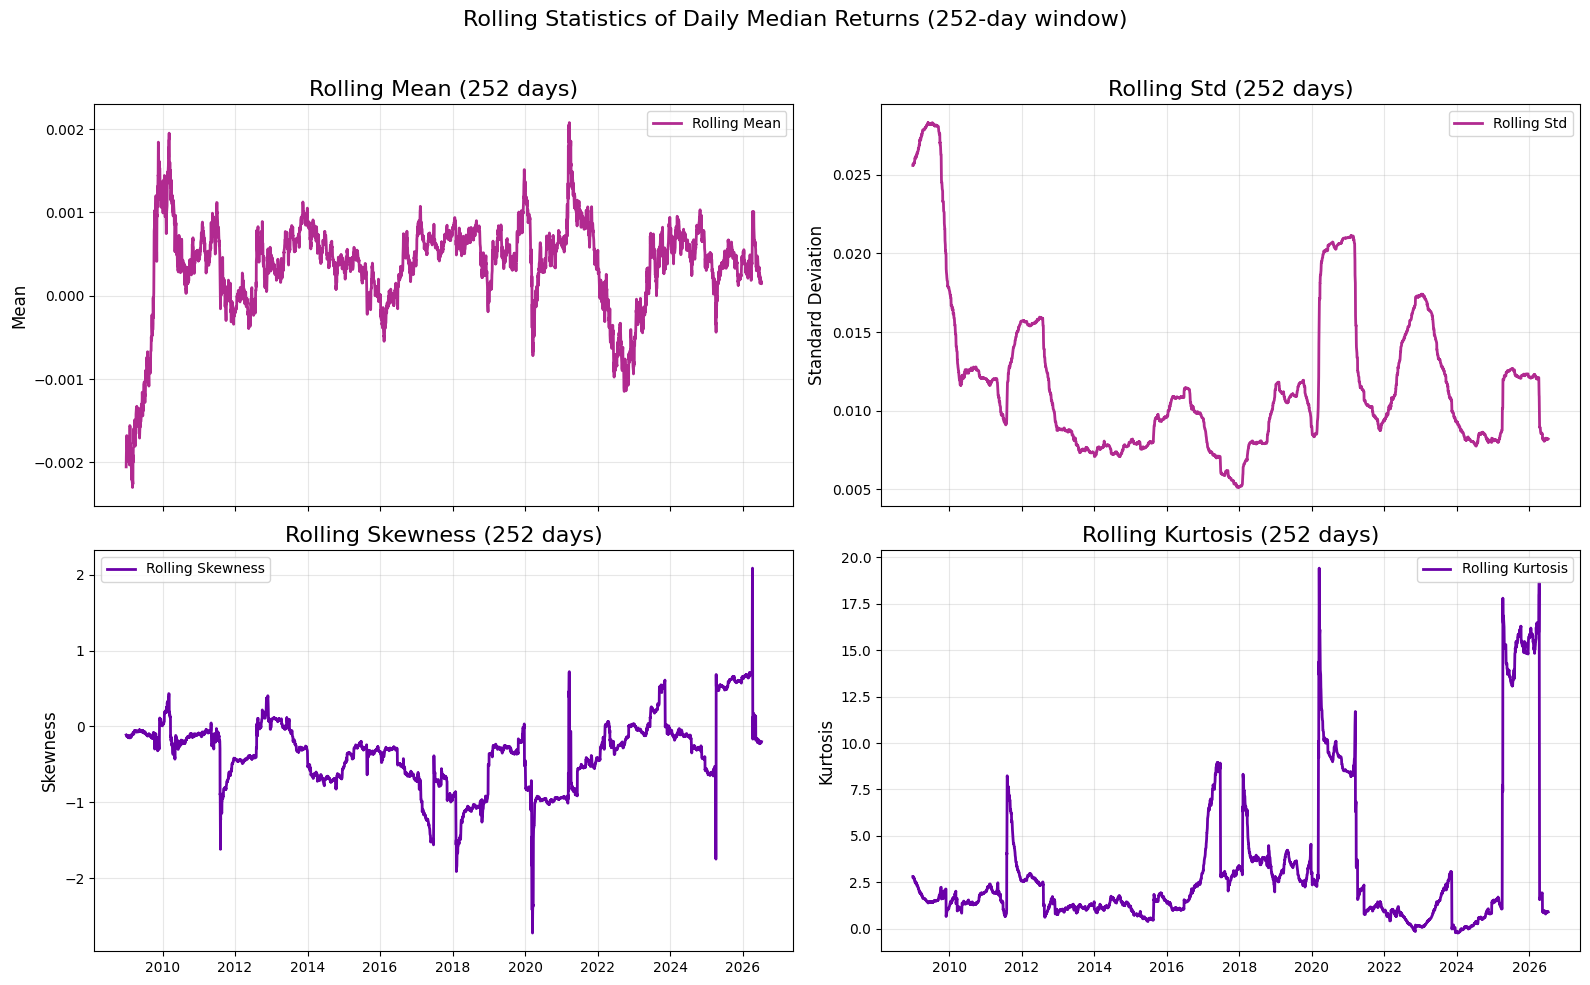

In [15]:
# Parametri
rolling_window = 252  # Finestra di 252 giorni (circa 1 anno di trading)

# Calcolo rolling statistics
rolling_mean = daily_median.rolling(window=rolling_window).mean()
rolling_std = daily_median.rolling(window=rolling_window).std()
rolling_skew = daily_median.rolling(window=rolling_window).apply(lambda x: skew(x, nan_policy='omit'), raw=False)
rolling_kurt = daily_median.rolling(window=rolling_window).apply(lambda x: kurtosis(x, nan_policy='omit'), raw=False)

# Creazione del multiplot
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# 1. Rolling Mean
axes[0, 0].plot(rolling_mean.index, rolling_mean, color=color2, label='Rolling Mean')
axes[0, 0].set_title('Rolling Mean (252 days)')
axes[0, 0].set_ylabel('Mean', fontsize=12)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

# 2. Rolling Std
axes[0, 1].plot(rolling_std.index, rolling_std, color=color2, label='Rolling Std')
axes[0, 1].set_title('Rolling Std (252 days)')
axes[0, 1].set_ylabel('Standard Deviation', fontsize=12)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

# 3. Rolling Skewness
axes[1, 0].plot(rolling_skew.index, rolling_skew, color=color1, label='Rolling Skewness')
axes[1, 0].set_title('Rolling Skewness (252 days)')
axes[1, 0].set_ylabel('Skewness', fontsize=12)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

# 4. Rolling Kurtosis
axes[1, 1].plot(rolling_kurt.index, rolling_kurt, color=color1, label='Rolling Kurtosis')
axes[1, 1].set_title('Rolling Kurtosis (252 days)')
axes[1, 1].set_ylabel('Kurtosis', fontsize=12)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

# Migliora il layout
plt.suptitle('Rolling Statistics of Daily Median Returns (252-day window)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Rolling Mean**:

- A marked recovery from early 2009 to late 2009, followed by fluctuations of around $ \pm 0.1–0.2 \%$ year-on-year.

- Sharp declines around March 2020 and early 2022.

**Rolling Std**:

- Peaks above $2–2.5\%$ during crises (2008–2009, 2011, 2015–2016, 2020, 2022).

- ‘Calm’ periods with standard deviation around $0.5–1\%$ in 2013–2014 and late 2016–2019.

**Rolling Skewness & Kurtosis**:
- More negative skewness (down to –2.5) during *crashes* (shortly before 2012, Covid).

- Kurtosis surging to extremely high values (up to 20) during extreme events.

These ‘tail indicators’ clearly show the volatility regimes and the non-stationarity of the process.

**N.B.: I could use rolling skewness and kurtosis as explicit features for the LSTM.**

### Cross-Sectional Volatility & Scatterplot

By cross-sectional volatility, we mean the standard deviation of the (daily) returns of individual tickers. This is useful for visualising ‘stress’ when plotted over time.

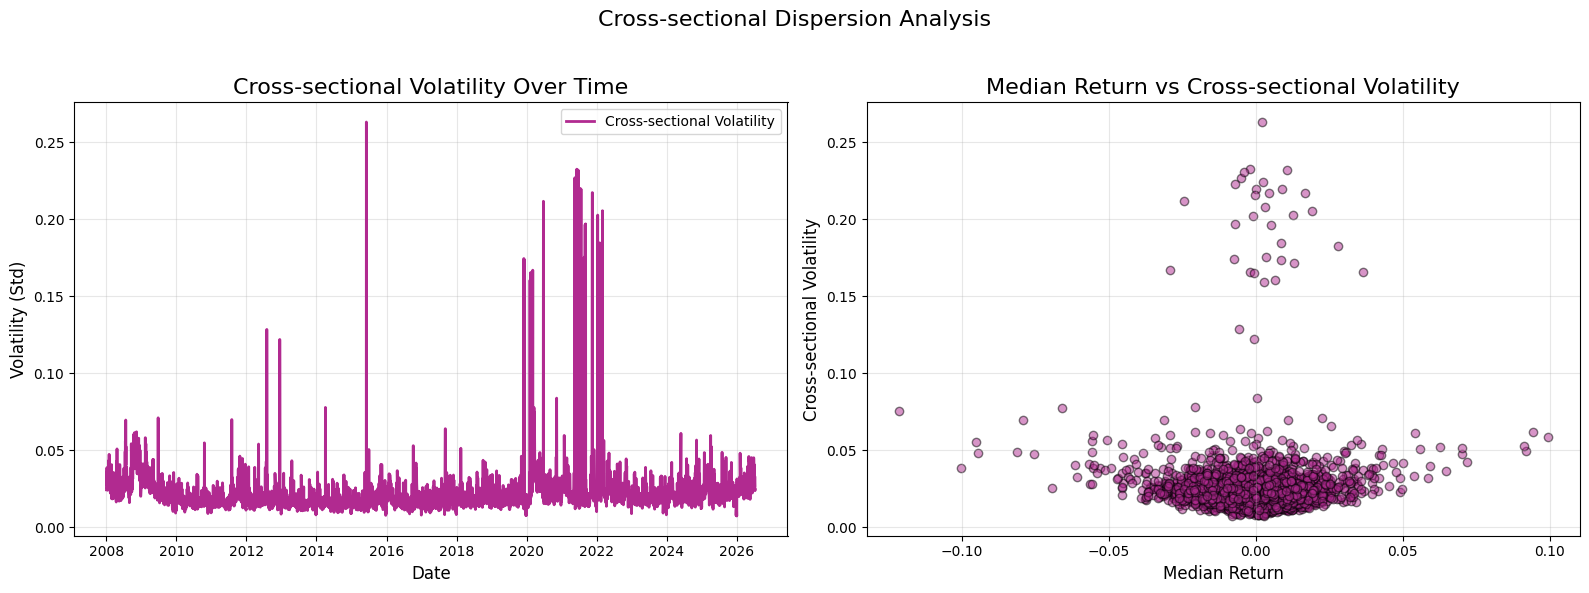

In [17]:
# Calcolo della cross-sectional volatility (std dei ritorni dei singoli tickers)
cross_sectional_vol = log_returns.std(axis=1)  # Deviazione standard giornaliera dei ritorni cross-sectional

# Crea il multiplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Line plot: Cross-sectional volatility nel tempo
axes[0].plot(cross_sectional_vol.index, cross_sectional_vol, color=color2, label='Cross-sectional Volatility')
axes[0].set_title('Cross-sectional Volatility Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Volatility (Std)')
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2. Scatter plot: Median return vs Cross-sectional volatility
axes[1].scatter(daily_median, cross_sectional_vol, alpha=0.5, color=color2, edgecolor='black')
axes[1].set_title('Median Return vs Cross-sectional Volatility')
axes[1].set_xlabel('Median Return')
axes[1].set_ylabel('Cross-sectional Volatility')
axes[1].grid(alpha=0.3)

# Migliora il layout
plt.suptitle('Cross-sectional Dispersion Analysis', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Time series**:

- Spikes in dispersion amongst tickers similar to those seen in the standard deviation of median returns, but of greater magnitude (up to 25 per cent).

- A good proxy for ‘market stress’ and a complementary measure to the volatility of the median return.

**Scatter plot of median return versus cross-sectional volatility**:

- A tight cluster around the mean (vol $\simeq2–5\%$), with ‘black/red day’ outliers at vol $\simeq 15–25\%$.

- There does not appear to be a strong linear correlation, but days with large losses tend to have higher volatility than days with sharp rises.

**NB
– Cross-sectional volatility is a potential ‘regime detection’ feature: when it rises above a certain threshold, the LSTM could handle the classification threshold differently.
– The fact that extreme outliers appear mainly during drawdowns suggests that a separate analysis of signals in ‘turbulent’ versus ‘calm’ regimes should be considered.**

## Phase 2: Data Split – Feature and Target Definition – LSTM Architecture

### Long Short-Term Memory (LSTM) Networks
LSTM networks belong to the class of Recurrent Neural Networks (RNNs). Unlike standard RNNs, LSTMs are specifically designed to learn long-term dependencies. Their architecture overcomes the inherent problems of traditional RNNs, such as gradient vanishing and exploding during the training phase, through the use of special memory cells and three gates (input, forget, output), which selectively decide whether to retain or discard information.

The network consists of an input layer, one or more hidden layers and an output layer. Its distinctive feature lies in the hidden layer, which contains the memory cells.

Each memory cell manages a cell state that is regulated by three gates acting as filters for information:

1. Forget Gate: determines which information should be removed from the cell’s state. It uses a *sigmoid* activation function that scales values between 0 (forget everything) and 1 (remember everything).

2. Input Gate: specifies which new information should be added to the cell’s state. This process combines a *sigmoid* function with a *tanh* function to calculate new ‘candidate values’.

3. Output Gate: determines which parts of the cell’s state should be sent to the next time step.

Sequential Processing:

- The network receives the input sequence one time step at a time. Once the last element of the sequence has been processed, the final output is returned.

- State Update: The new state of the cell is calculated by multiplying the old state by the forget gate and adding the product of the input gate and the new candidate values.

### Study Period
Here, we use the same methodology employed by Fischer & Krauss to divide historical data into time blocks suitable for model training and testing.

- **Study period:** defined as a single block comprising a training set and a trading set.

- **Temporal composition of the study period:** each block spans 1,000 days and is divided as follows:

    (i): **Training period:** the first 750 days, used for training (in-sample).

    (ii): **Trading period:** the last 250 days, used for out-of-sample forecasts and trading simulations.

- **Rolling windows mechanism:**

    The entire dataset is divided into 15 study periods.

    At the end of each trading year (250 days), the entire system, starting from the beginning, is advanced by 250 days to commence a new study period, ensuring that trading days do not overlap with training periods already considered.

- **Training and forecasting logic:** Over the course of the 750-day training period, the model is trained by feeding it 240 days’ worth of input data (look-back) to predict the value for the following day. Once training is complete, the parameters determined are used to trade over the subsequent 250 days, which the model has never ‘seen’ before (fully out-of-sample).

- **Dynamic selection of securities ($n_i$):** only those securities for which data is available for the entire training period of the specific study period are selected.

    The **training set** includes all $n_i$ securities for which historical data is available.

    The **trading set** always considers the same $n_i$ securities.


### Features and Targets
Below we show the transformation of raw financial data into features and targets suitable for training the LSTM network.

#### Features – return sequences for LSTM networks
Unlike memory-free models (such as Random Forests), which receive returns calculated over different time horizons as static inputs, the LSTM network requires time series.

- Calculation of simple returns: for each security $s$ at time $t$, the simple one-day return ($m=1$) is calculated:

$$R_{1,s,t} = \frac{P_{s,t}}{P_{s,t-1}} - 1 \, ,$$

where $P_{s,t}$ is the price.

- Feature vector: all one-day returns are aggregated into a large feature vector $V$ of dimension $n_i \times T_{study}$ (where $n_i$ is the number of securities and $T_{study}$ is the duration of the study period).

- Standardisation: the returns are normalised as follows to facilitate the network’s learning:

$$\tilde{R}_{1,s,t} = \frac{R_{1,s,t} - \mu_{train}}{\sigma_{train}} \, .$$

It is essential that the mean ($\mu$) and standard deviation ($\sigma$) are calculated exclusively on the training set to avoid look-ahead bias.

- Sequence construction: the LSTM network is fed sequences of 240 consecutive standardised daily returns, corresponding to approximately one year of trading.

    The sequences overlap: the first sequence for a security covers days 1 to 240, the second days 2 to 241, and so on.

    In total, approximately 51,000 sequences are generated for each study period (assuming a number of windows per training period of $=750 - 240 = 510$ windows per ticker. Assuming $\sim 100$ valid tickers, this gives a total of $510,000$ windows), of which 38,250 are used for training and 12,750 for out-of-sample forecasts.

#### Targets
The aim of the network is not to predict the exact price, but to solve a binary classification problem based on the relative performance of the security compared with the rest of the market,

- Cross-sectional sorting: for each period $t+1$, all one-day returns ($R_{1,s,t+1}$) for all securities are sorted in ascending order.

- Definition of classes: the dataset is divided into two classes of equal size based on the median of the returns:

    (i) **Class 0:** The security has a return below the cross-sectional median (underperforms the market).

    (ii) **Class 1:** The security has a return greater than or equal to the cross-sectional median (it outperforms the market).

- Purpose of the model: during the forecasting phase, the LSTM network outputs the probability that a security belongs to Class 1 (i.e. the probability of outperforming the median on day $t+1$).

In summary, the pipeline transforms a historical price series into thousands of standardised sequences (input), with the aim of classifying whether the security will be a ‘winner’ or a ‘loser’ relative to the market median on the following day (output).

### Technical characteristics of the LSTM used by Fischer & Krauss

#### Cost function:
They use cross-entropy, as the study is based on binary classification (predicting whether a stock will outperform the market median). Cross-entropy is a standard cost function used in classification problems. It measures the error between the probability predicted by the model and the actual class. The higher the value, the less accurate the model. When the model predicts an incorrect outcome with a high probability, the cost increases exponentially.

#### Calculation of parameters (weights and biases)
The total number of parameters (weights and bias terms) to be trained in an LSTM layer is calculated based on the number of hidden units (h) and the number of input features (i) according to the expression
$$4 (h (i+1) + h^2) \, ,$$
specifically, the parameter structure is broken down as follows:

- $4hi$: dimensions of the four weight matrices applied to the inputs of each gate.
- $4h$: dimensions of the four bias vectors.
- $4h^2$: dimensions of the weight matrices applied to the outputs of the previous timestamps.

#### Training methodology
The network is trained using three advanced techniques implemented via the Keras library:

1. RMSprop: This is used as the optimiser. It is a ‘mini-batch’ version of rprop and is considered in the literature to be an optimal choice for recurrent neural networks.

2. Dropout Regularisation: This involves randomly ‘hiding’ a fraction of the input units from both the input gates and the recurrent connections during each training update. It serves to reduce the risk of overfitting and improve the model’s generalisation ability. The authors chose a value of 0.1, as higher values led to a decline in performance.

3. Early Stopping: A technique used to dynamically determine the number of training epochs and further reduce overfitting. Training is halted if the loss on the validation set does not decrease for a pre-set number of periods (patience), after which the weights of the model that recorded the lowest loss are restored

#### Dataset splitting
The training samples for each study period are randomly split into two sets:

- Training set (80%): used to train the network and tune the parameters.

- Validation set (20%): used to monitor the loss on unseen data and trigger early stopping.

#### LSTM network topology
The specific architecture chosen by the authors comprises:

- Input layer: accepts sequences with one feature (standardised return) and 240 time steps

- LSTM Layer: comprising $h=25$ hidden neurons and a dropout value of 0.1. This configuration generates a total of 2,752 parameters, ensuring a robust ratio of approximately 93 training examples per parameter to mitigate data noise.

- Output layer: A single dense neuron and a sigmoid activation function.


### Forecasting – Ranking – Trading Strategy
The LSTM model operates according to a specific pipeline to transform the network’s output into operational decisions:

- probability prediction: for each security $s$ and each period $t+1$, the LSTM network estimates the probability $P_{s,t+1|t}$ that the security will outperform (class 1) or underperform (class 0) the median of the market’s cross-sectional returns. This prediction is made using only the information available up to time $t$.

- ranking: once the probabilities for all securities in the dataset have been obtained, they are ranked in descending order based on the probability of belonging to class 1.

- portfolio construction: the securities at the top of the ranking are considered to be those with the highest probability of outperforming the market; consequently, the strategy involves:

    1. Taking a long position (purchase) in the top k securities in the ranking.

    2. Take a short position (short selling) on the worst k stocks (k flops) in the ranking.

    3. The result is a long-short portfolio comprising a total of 2k stocks.


#### Analysis of returns

- portfolio size (k): for simplicity, a single portfolio size of $k=10$ is tested.

#### Evaluation metrics used

1. mean_return_%: The average daily percentage return generated by the portfolio, obtained using the long-short strategy. It measures the average profitability of the strategy. A positive value indicates that, on average, the strategy generates daily profits.
$$mean\_return\_\% = \frac{\sum_{t=1}^{T} r_t}{T} \times 100 \, ,$$
where $r_t$ is the daily return of the portfolio on day $t$ and $T$ is the total number of trading days.

2. std_return_%: This is the standard deviation of the long-short portfolio’s daily percentage returns. It measures the strategy’s volatility, i.e. its risk.
$$std\_return\_\% = \sqrt{\frac{\sum_{t=1}^{T} (r_t - \bar{r})^2}{T}} \times 100 \, ,$$
where $\bar{r}$ is the average daily return of the portfolio.

3. sharpe_annual: Annualised Sharpe ratio. This is the ratio of the long-short portfolio’s average daily return to its standard deviation, annualised. It measures the strategy’s risk-adjusted return. It therefore measures the strategy’s efficiency in terms of return per unit of risk.
$$ sharpe\_annual = \frac{\text{mean\_return\_\%} / 100}{\text{std\_return\_\%} / 100} \times \sqrt{252} \, ,$$
where 252 is the average number of trading days within a year.

4. trade_accuracy: This is the percentage of correct predictions out of the total number of predictions made. It indicates how often the model correctly predicts whether a security will outperform or underperform the daily median. It measures the model’s ability to correctly classify the daily returns of securities relative to the median. An accuracy of over 50 per cent indicates that the model performs better than a random prediction.
$$trade_accuracy = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}} \, .$$



In [17]:
# Creazione study periods

# Come metrica prendo i normali returns (percentuali)
returns = adj_close.pct_change()  # Calcola i ritorni giornalieri percentuali r_t = (P_t - P_{t-1}) / P_{t-1}
returns = returns.dropna(how='all')  # Rimuove eventuali NaN

# Per ogni giorno calcolo la mediana cross-sectionale
# (solo sui ticker che hanno un rendimento valido quel giorno)
median_daily = returns.median(axis=1)       # Serie con indice = Date 

# Vediamo come si distribuiscono i periodi sul dataset
# Assumiamo che 'returns' abbia l'indice Date già allineato (dal 1996-01-03 in poi)
dates = returns.index
print("First date:", dates[0])
print("Last date:", dates[-1])
print("Total number of trading days:", len(dates))

# Parametri del paper
train_len   = 750
trade_len   = 250
study_len   = train_len + trade_len          # 1000
roll_step   = 250                            # scorrimento

# Generiamo le finestre
study_periods = []
start_idx = 0

while start_idx + study_len <= len(dates):
    train_start = start_idx
    train_end   = start_idx + train_len - 1          # inclusivo
    trade_start = start_idx + train_len
    trade_end   = start_idx + study_len - 1
    
    study_periods.append({
        'study_id'          : len(study_periods) + 1,
        'train_start_date'  : dates[train_start],
        'train_end_date'    : dates[train_end],
        'trade_start_date'  : dates[trade_start],
        'trade_end_date'    : dates[trade_end],
        'n_days_total'      : study_len
    })
    
    start_idx += roll_step 

print(f"\nNumber of study periods: {len(study_periods)}")
for p in study_periods[:3]:
    print(p)
print("...")
for p in study_periods[-3:]:
    print(p)

Prima data: 2008-01-03 00:00:00
Ultima data: 2026-07-10 00:00:00
Totale giorni di trading: 4658

Numero di study periods generati: 15
{'study_id': 1, 'train_start_date': Timestamp('2008-01-03 00:00:00'), 'train_end_date': Timestamp('2010-12-22 00:00:00'), 'trade_start_date': Timestamp('2010-12-23 00:00:00'), 'trade_end_date': Timestamp('2011-12-19 00:00:00'), 'n_days_total': 1000}
{'study_id': 2, 'train_start_date': Timestamp('2008-12-30 00:00:00'), 'train_end_date': Timestamp('2011-12-19 00:00:00'), 'trade_start_date': Timestamp('2011-12-20 00:00:00'), 'trade_end_date': Timestamp('2012-12-18 00:00:00'), 'n_days_total': 1000}
{'study_id': 3, 'train_start_date': Timestamp('2009-12-28 00:00:00'), 'train_end_date': Timestamp('2012-12-18 00:00:00'), 'trade_start_date': Timestamp('2012-12-19 00:00:00'), 'trade_end_date': Timestamp('2013-12-16 00:00:00'), 'n_days_total': 1000}
...
{'study_id': 13, 'train_start_date': Timestamp('2019-12-03 00:00:00'), 'train_end_date': Timestamp('2022-11-22 0

## Phase 3: Model Analysis

### Preprocessing
- Ticker-by-ticker standardisation. $\mu$ and $\sigma$ calculated solely on the 750 training days to avoid look-ahead.

- Creation of sequences of length 240 days per ticker, excluding windows containing NaN

### LSTM Training

- Stratified 80/20 split for training/validation (focus on optimisation).

- Early stopping based on validation loss; best model saved.

### LSTM Evaluation
- In-sample metrics: number of epochs run, training and validation loss/accuracy, validation AUC.

- Out-of-sample: classification accuracy, average daily return, volatility, Sharpe ratio of the long-short strategy (k=10).

### Random Forest Baseline
-  Training of a Random Forest on the same data (sequences ‘flattened’ as feature vectors).

- Same evaluation metrics and same long-short strategy.

- Ensemble of **decision trees** trained using the _bagging_ method:
  1. Each tree is constructed using a random sample (bootstrap) from the training set.
  2. At each split, a random subset of features is selected, increasing diversity and reducing overfitting

### Logging and reproducibility
- NumPy and TensorFlow seeds are fixed for each study period.

- Logging of the number of tickers, train/val/trade sequences, selected parameters and metrics for each model.

- Key metrics are printed to the screen at each iteration to monitor progress.

### Focal Loss
Focal Loss is a generalisation of traditional binary cross-entropy that introduces a modulation factor to place greater weight on examples that are difficult to classify. For each sample with label $(y \in \{0,1\})$ and prediction $(p = \hat{y} = \sigma(z))$, the Focal Loss is written as:

$$
\text{FL}(p_t) = -\,\alpha \,(1 - p_t)^\gamma \,\log(p_t)
$$

dove:
- $p_t = \begin{cases}
p       & \text{se } y=1,\\
1 - p   & \text{se } y=0,
\end{cases}$
- $\alpha \in [0,1]$ is a class balancing factor,
- $\gamma \ge 0$ is the _focusing parameter_ that controls the reduction in weighting for easy examples.

We chose it for the following reasons:

- Noisy boundary class: In our cross-sectional return classification problem, many trading days have weak signals (returns close to the median), so the network tends to overestimate the easy examples and neglect the borderline ones.

- Reducing overfitting on easy cases: The term $(1 - p_t)^\gamma$ (where $\gamma \geq 0$) de-emphasises the loss from examples already classified with high confidence $(p_t\to1)$, focusing optimisation on ‘difficult’ samples $(p_t\approx0.5)$. We choose $\gamma=2$ because, according to the paper by the authors who proposed this loss function, values of $\gamma \sim 5$ result in unstable training, where optimisation is driven towards the most extreme outliers. $\gamma = 2$ seemed to us to be a good compromise

- Class balancing: With $\alpha\neq 0.5$, we can assign greater weight (e.g. ($\alpha=0.25$)) to the rare or more critical class (in this case, the ‘overperforming’ class), thereby improving sensitivity to weak signals.

- Comparative experiments: We therefore compared standard cross-entropy with Focal Loss to verify whether a loss function focused on difficult cases produces a better Sharpe ratio or higher out-of-sample accuracy.

In [20]:
# ============================================================
# Parametri globali
# ============================================================
LOOKBACK    = 240
K           = 10
TRAIN_DAYS  = 750
TRADE_DAYS  = 250
STUDY_LEN   = TRAIN_DAYS + TRADE_DAYS

# Numero massimo di study periods
MAX_PERIODS = 10

# ============================================================
# Focal loss 
# ============================================================
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        return -tf.reduce_mean(alpha * tf.pow(1.0 - pt, gamma) * tf.math.log(pt))
    return loss

# ============================================================
# Funzione per creare sequenze e labels, eliminando ticker con NaN nella finestra
# ============================================================
def create_sequences_and_labels(returns_df, labels_df, lookback=LOOKBACK):
    '''
    Crea sequenze temporali di lunghezza lookback (finestra di osservazione) 
    e le corrispondenti etichette (labels) per ogni ticker, eliminando i ticker che contengono 
    valori NaN nella finestra corrente.
    
    Logica: Per ogni giorno t a partire da lookback fino alla fine del dataset:
    1. Prende la finestra di ritorni dei giorni [t-lookback, t-1] per tutti i ticker.
    2. Controlla quali ticker hanno valori validi (non NaN) in tutta la finestra.
    3. Per ogni ticker valido, crea una sequenza di rendimenti (lookback,1), associa l'etichetta del giorno t
    e aggiunge la sequenza alla lista X_list.
    4. La label associata a y_list è quella del giorno t per il ticker corrente.
    
    Ritorna:
    - X: array di sequenze di forma (n_sequences, lookback, 1)
    - y: array di etichette di forma (n_sequences,)
    '''
    X_list, y_list = [], []
    dates = returns_df.index
    tickers = returns_df.columns
    for t in range(lookback, len(dates)):           # Iterazione su ogni giorno t a partire da lookback fino alla fine del dataset
        window = returns_df.iloc[t-lookback:t]      # Finestra di ritorni dei giorni [t-lookback, t-1] per tutti i ticker
        lab_row = labels_df.iloc[t]                 # Etichette del giorno t per tutti i ticker
        # selezione dei ticker senza NaN nella finestra
        valid = window.columns[window.notnull().all(axis=0)]
        for tk in valid:
            seq = window[tk].values.reshape(lookback, 1)
            X_list.append(seq)
            y_list.append(lab_row[tk])
    X = np.array(X_list)   # shape (n_sequences, lookback, 1)
    y = np.array(y_list)   # shape (n_sequences,)
    return X, y

# ============================================================
# Builder LSTMs
# ============================================================
def build_lstm_baseline():
    '''
    Architettura:
    - 25 hidden units
    - accetta come input una sequenza di lunghezza LOOKBACK con 1 feature (ritorno normalizzato)
    - utilizza dropout e recurrent dropout del 10%
    - singolo neurone con funzione di attivazione sigmoid per produrre una probabilità binaria
    Compilazione:
    - loss: binary_crossentropy
    - optimizer: RMSprop (in letteratura Adam è spesso usato, ma RMSprop è più stabile per LSTM)
    - metrics: accuracy
    '''
    m = Sequential([
        LSTM(25, input_shape=(LOOKBACK,1), dropout=0.1, recurrent_dropout=0.1),
        Dense(1, activation='sigmoid')
    ])
    m.compile(loss='binary_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])
    return m

def build_lstm_focal():
    m = Sequential([
        LSTM(25, input_shape=(LOOKBACK,1), dropout=0.1, recurrent_dropout=0.1),
        Dense(1, activation='sigmoid')
    ])
    m.compile(loss=focal_loss(gamma=2.0, alpha=0.25),
              optimizer=RMSprop(),
              metrics=['accuracy'])
    return m

# ============================================================
# Calcolo metriche long-short
# ============================================================
def compute_long_short_metrics(y_pred_proba, returns_raw, k=K):
    '''
    Funzione per calcolare le metriche di performance di una strategia long-short basata sulle probabilità previste dal modello.

    Funzionamento generale:
    - La funzione prende in input le probabilità previste dal modello (`y_pred_proba`) e i rendimenti reali (`returns_raw`) dei titoli.
    - Per ogni giorno, i titoli vengono ordinati (ranking) in base alle probabilità previste di sovraperformare la mediana.
    - Si costruisce un portafoglio long-short:
        - Long: si assumono posizioni long sui primi `k` titoli con probabilità più alte.
        - Short: si assumono posizioni short sugli ultimi `k` titoli con probabilità più basse.
    - Il rendimento giornaliero del portafoglio è calcolato come la differenza tra il rendimento medio dei titoli long e quello dei titoli short, diviso per 2
        (la divisione per due è una convenzione per bilanciare il contributo delle due componenti).
    - Infine, si calcolano:
        - `mean_ret`: rendimento medio giornaliero del portafoglio (in percentuale).
        - `std_ret`: deviazione standard giornaliera dei rendimenti del portafoglio (in percentuale).
        - `sharpe`: Sharpe ratio annualizzato, che misura il rendimento aggiustato per il rischio.

    Note:
    - Il ranking dei titoli viene effettuato ogni giorno in base alle probabilità previste.
    - Il rendimento medio del portafoglio (`mean_ret`) viene calcolato mediando i rendimenti giornalieri sul trading set.
    '''

    n_tickers = returns_raw.shape[1]                    # Numero di titoli
    n_days = len(y_pred_proba) // n_tickers             # Numero di giorni nel trading set
    y_pred = y_pred_proba.reshape(n_days, n_tickers)    # Reshape delle probabilità previste in una matrice (n_days, n_tickers)

    # Selezione dei rendimenti reali corrispondenti al trading set
    returns_d = returns_raw[-n_days:, :]    # Matrice dei rendimenti giornalieri (n_days, n_tickers)
    port_rets = []                          # Lista per salvare i rendimenti giornalieri del portafoglio

    # Loop sui giorni del trading set
    for d in range(n_days):
        probs = y_pred[d]  # Probabilità previste per il giorno d
        
        # prob alte -> classe 1 (alta prob di sovraperformare)
        # prob basse -> classe 0 (bassa prob di sovraperformare)

        # Controllo che ci siano almeno 2*k titoli validi per costruire il portafoglio
        if len(probs) >= 2 * k:
            ranked = np.argsort(-probs)                     # Ranking dei titoli in base alle probabilità (decrescente)
            long_ret = returns_d[d, ranked[:k]].mean()      # Calcolo del rendimento medio dei titoli long (top k)
            short_ret = returns_d[d, ranked[-k:]].mean()    # Calcolo del rendimento medio dei titoli short (bottom k)
            port_rets.append((long_ret - short_ret) / 2)    # Rendimento giornaliero del portafoglio long-short

    port_rets = np.array(port_rets)     # lista dei rendimenti giornalieri in un array NumPy
    mean_ret = port_rets.mean() * 100   # rendimento medio giornaliero del portafoglio (in percentuale)
    std_ret = port_rets.std() * 100     # deviazione standard giornaliera dei rendimenti (in percentuale)
    sharpe = ((mean_ret / 100) / (std_ret / 100)) * np.sqrt(252) if std_ret > 0 else np.nan    # Sharpe ratio annualizzato

    return mean_ret, std_ret, sharpe

# ============================================================
# Main loop sui study periods
# ============================================================
all_results = []
for i, sp in enumerate(study_periods):
    if i >= MAX_PERIODS:
        break

    # riproducibilità
    seed = 42 + sp['study_id']
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # estrazione blocco train+trade per lo study period corrente
    mask = (returns.index >= sp['train_start_date']) & (returns.index <= sp['trade_end_date'])
    block = returns.loc[mask].copy()
    
    # FILTRO TICKER CON DATI COMPLETI SUL BLOCCO INTERO
    #    (evitiamo NaN sporadici che spezzano la griglia)
    block = block.dropna(axis=1, how='any')
    n_tk = block.shape[1]
    if n_tk < 30:       # scarto study period se ci sono meno di 30 ticker validi
        continue

    # mediana giornaliera e creazione delle labels binarie
    median_daily = block.median(axis=1)
    labels_blk   = (block >= median_daily.values.reshape(-1,1)).astype(int)\
                       .shift(-1).dropna()          # shift(-1) perché vogliamo prevedere il giorno successivo
    block        = block.loc[labels_blk.index]      # allineamento con le labels
    returns_raw  = block.values                     # salvataggio rendimenti grezzi per calcolo metriche

    # standardizzazione (solo sul train set)
    train_mask = block.index <= sp['train_end_date']
    mu         = block[train_mask].mean(axis=0)
    sigma      = block[train_mask].std(axis=0).replace(0,1) # evito divisioni per 0
    block_std  = (block - mu) / sigma

    # creazione sequenze (ora per ogni t in train+trade e ogni tk valido
    # abbiamo esattamente una sequenza)
    X_all, y_all = create_sequences_and_labels(block_std, labels_blk)
    # calcolo numero di sequenze di train e trade
    n_train_seq = n_tk * (TRAIN_DAYS - LOOKBACK + 1)    # sequenze training
    n_trade_seq = n_tk * TRADE_DAYS                     # sequenze trading
    X_train_all = X_all[:n_train_seq]
    y_train_all = y_all[:n_train_seq]
    X_trade     = X_all[n_train_seq:n_train_seq + n_trade_seq]
    y_trade     = y_all[n_train_seq:n_train_seq + n_trade_seq]

    # split train/val (stratified, per ottimizzazione iperparametri)
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.20, random_state=seed, stratify=y_train_all
    )
    n_val_seq = len(X_val)  # quante sequenze ci sono nel validation set

    # early stopping comune
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)

    # === 1) LSTM baseline ===
    model_bs = build_lstm_baseline()
    model_bs.fit(X_tr, y_tr,
                 validation_data=(X_val,y_val),
                 epochs=50, batch_size=512,
                 callbacks=[es], verbose=0)
    # valutazione
    y_val_bs  = model_bs.predict(X_val, verbose=0).ravel()
    val_acc_bs= ( (y_val_bs>=0.5).astype(int)==y_val ).mean()
    val_auc_bs= roc_auc_score(y_val, y_val_bs)
    y_tr_bs   = model_bs.predict(X_trade, verbose=0).ravel()
    trade_acc_bs, mean_bs, std_bs, sharpe_bs = (
        ( (y_tr_bs>=0.5).astype(int)==y_trade ).mean(),
        *compute_long_short_metrics(y_tr_bs, returns_raw, K)
    )

    # === 2) LSTM focal loss ===
    model_fc = build_lstm_focal()
    model_fc.fit(X_tr, y_tr,
                 validation_data=(X_val,y_val),
                 epochs=50, batch_size=512,
                 callbacks=[es], verbose=0)
    y_val_fc  = model_fc.predict(X_val, verbose=0).ravel()
    val_acc_fc= ( (y_val_fc>=0.5).astype(int)==y_val ).mean()
    val_auc_fc= roc_auc_score(y_val, y_val_fc)
    y_tr_fc   = model_fc.predict(X_trade, verbose=0).ravel()
    trade_acc_fc, mean_fc, std_fc, sharpe_fc = (
        ( (y_tr_fc>=0.5).astype(int)==y_trade ).mean(),
        *compute_long_short_metrics(y_tr_fc, returns_raw, K)
    )

    # === 3) Random Forest baseline ===
    X_tr_f = X_tr.reshape(len(X_tr), LOOKBACK)
    X_val_f= X_val.reshape(len(X_val), LOOKBACK)
    X_trd_f= X_trade.reshape(len(X_trade), LOOKBACK)
    
    rf = RandomForestClassifier(n_estimators=100,  # numero di alberi nell'ensemble
                                random_state=seed, # per riproducibilità delle stime
                                n_jobs=-1)
    
    rf.fit(X_tr_f, y_tr)
    y_val_rf = rf.predict_proba(X_val_f)[:,1]
    val_acc_rf = (rf.predict(X_val_f)==y_val).mean()
    val_auc_rf = roc_auc_score(y_val, y_val_rf)
    y_tr_rf   = rf.predict_proba(X_trd_f)[:,1]
    trade_acc_rf, mean_rf, std_rf, sharpe_rf = (
        ( (y_tr_rf>=0.5).astype(int)==y_trade ).mean(),
        *compute_long_short_metrics(y_tr_rf, returns_raw, K)
    )

    # stampa a video delle metriche principali
    print(f"\n=== Study {sp['study_id']} "
          f"({sp['train_start_date'].date()}→{sp['trade_end_date'].date()}) ===")
    print(f"LSTM-baseline   | tickers={n_tk} | val_acc={val_acc_bs:.4f} | val_auc={val_auc_bs:.4f} | "
          f"trade_acc={trade_acc_bs:.4f} | mean={mean_bs:.3f}% | std={std_bs:.3f}% | sharpe={sharpe_bs:.3f}")
    print(f"LSTM-focal-loss | tickers={n_tk} | val_acc={val_acc_fc:.4f} | val_auc={val_auc_fc:.4f} | "
          f"trade_acc={trade_acc_fc:.4f} | mean={mean_fc:.3f}% | std={std_fc:.3f}% | sharpe={sharpe_fc:.3f}")
    print(f"RandomForest    | tickers={n_tk} | val_acc={val_acc_rf:.4f} | val_auc={val_auc_rf:.4f} | "
          f"trade_acc={trade_acc_rf:.4f} | mean={mean_rf:.3f}% | std={std_rf:.3f}% | sharpe={sharpe_rf:.3f}")

    # salva risultati
    for model_name, mres in [
        ('LSTM_baseline', (val_acc_bs, val_auc_bs, trade_acc_bs, mean_bs, std_bs, sharpe_bs)),
        ('LSTM_focal',    (val_acc_fc, val_auc_fc, trade_acc_fc, mean_fc, std_fc, sharpe_fc)),
        ('RF',            (val_acc_rf, val_auc_rf, trade_acc_rf, mean_rf, std_rf, sharpe_rf)),
    ]:
        all_results.append({
            'study_id'     : sp['study_id'],
            'model'        : model_name,
            'n_tickers'    : n_tk,
            'n_train_seq'  : len(X_tr),
            'n_val_seq'    : n_val_seq,
            'n_trade_seq'  : n_trade_seq,
            'val_acc'      : mres[0],
            'val_auc'      : mres[1],
            'trade_acc'    : mres[2],
            'mean_return_%': mres[3],
            'std_return_%' : mres[4],
            'sharpe_annual': mres[5]
        })


# ============================================================
# Salvataggio dei risultati
# ============================================================
results_df = pd.DataFrame(all_results)
results_df.to_csv("nasdaq100_lstm_vs_rf.csv", index=False)
print("\nFine esecuzione, risultati salvati in nasdaq100_lstm_vs_rf.csv")



=== Study 1 (2008-01-03→2011-12-19) ===
LSTM-baseline   | tickers=139 | val_acc=0.5061 | val_auc=0.5189 | trade_acc=0.5045 | mean=0.033% | std=0.616% | sharpe=0.852
LSTM-focal-loss | tickers=139 | val_acc=0.5053 | val_auc=0.5107 | trade_acc=0.5042 | mean=-0.021% | std=0.564% | sharpe=-0.597
RandomForest    | tickers=139 | val_acc=0.5365 | val_auc=0.5538 | trade_acc=0.4993 | mean=-0.011% | std=0.432% | sharpe=-0.396

=== Study 2 (2008-12-30→2012-12-18) ===
LSTM-baseline   | tickers=141 | val_acc=0.5119 | val_auc=0.5092 | trade_acc=0.5042 | mean=0.022% | std=0.643% | sharpe=0.548
LSTM-focal-loss | tickers=141 | val_acc=0.5054 | val_auc=0.5065 | trade_acc=0.5039 | mean=-0.003% | std=0.607% | sharpe=-0.091
RandomForest    | tickers=141 | val_acc=0.5289 | val_auc=0.5459 | trade_acc=0.4982 | mean=-0.044% | std=0.461% | sharpe=-1.507

=== Study 3 (2009-12-28→2013-12-16) ===
LSTM-baseline   | tickers=144 | val_acc=0.5049 | val_auc=0.5085 | trade_acc=0.4989 | mean=0.027% | std=0.455% | sharpe=

Observations:

- Random Forest often achieves a value of a few percentage points above $50\%$ in the validation set, which can even fall below $50\%$ on trading days, and the mean return and Sharpe ratio almost always turn negative. This phenomenon is due to memory-free overfitting. The model learns to distinguish noisy in-sample data but fails to capture regime patterns that generalise. LSTMs have modest val_acc (around 0.50) but stable trade_acc slightly above 0.50 and, above all, generate positive Sharpe ratios.

- It may happen that two models have the same trade_acc but produce different returns. Accuracy measures only the proportion of correct labels, but does not take into account the magnitude of the returns on those days. In the same period, for example period 5 where both LSTMs have a trade_acc of 0.5017, the baseline may have correctly predicted the larger upward movements more often, whilst the model with focal loss may have predicted those with lower returns.

- In the first two study periods (2008–2012), the ‘focal loss’ strategy had a negative Sharpe ratio or one significantly lower than the baseline. In periods 3 and 4 (approximately 2009–2014), the ‘focal loss’ strategy ‘stands out’ with a Sharpe ratio > 1 and as high as $\sim 2.8$ in study 4. From 2015 onwards, it returns to being weaker than the baseline. Focal loss appears to help during intermediate market phases (neither too turbulent nor too calm), whilst in deep crises (2008–2009) and in more efficient markets post-2015, it penalises the model.

- LSTMs consistently have a std_return of around $0.5–0.6\%$, whilst RF hovers around $0.35–0.45\%$. RF therefore generates returns with very low volatility, but this is not sufficient to produce a positive Sharpe ratio.

- The LSTM baseline manages to increase mean_return sufficiently to justify the volatility and risk, whilst the focal loss often reduces std_return but sometimes reduces mean_return even further.

- The LSTM-baseline’s val_auc fluctuates between 0.50 and 0.52, but does not appear to be linearly correlated with the Sharpe ratio (e.g. in period 6, val_auc $\simeq 0.50$ but the Sharpe ratio $\simeq 2.27$). This means that the in-sample val_auc ‘proxy’ is not a good predictor of trading performance.


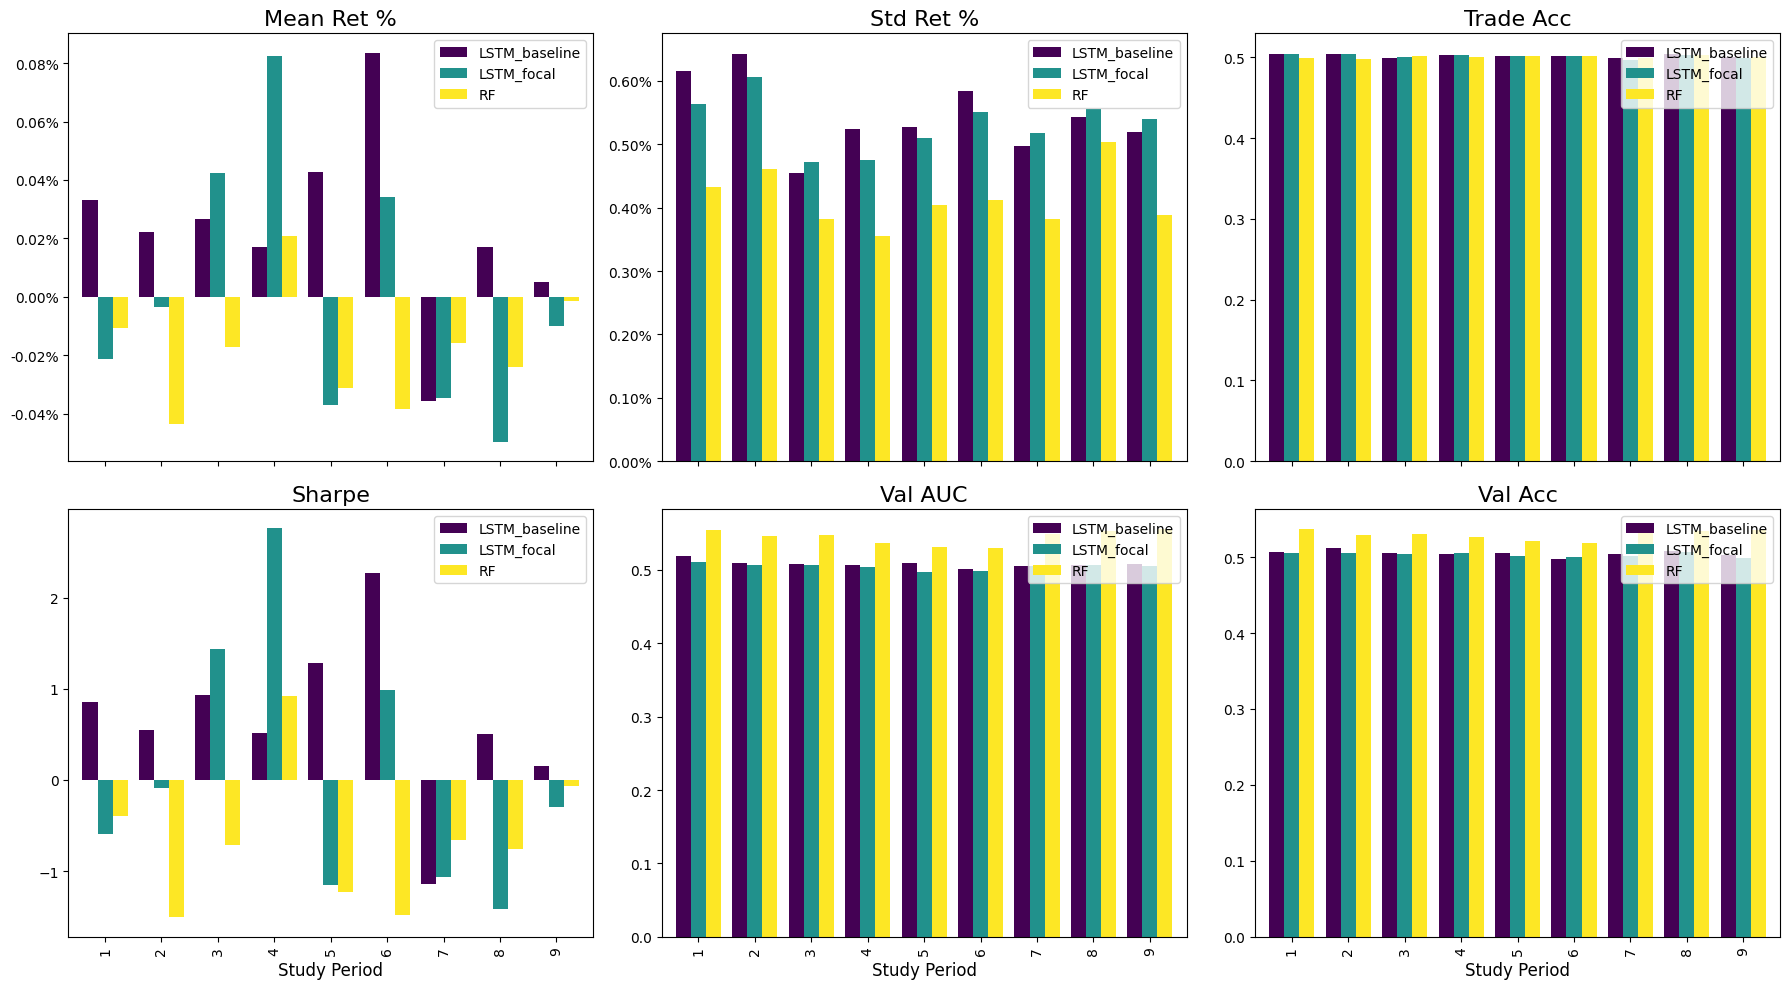

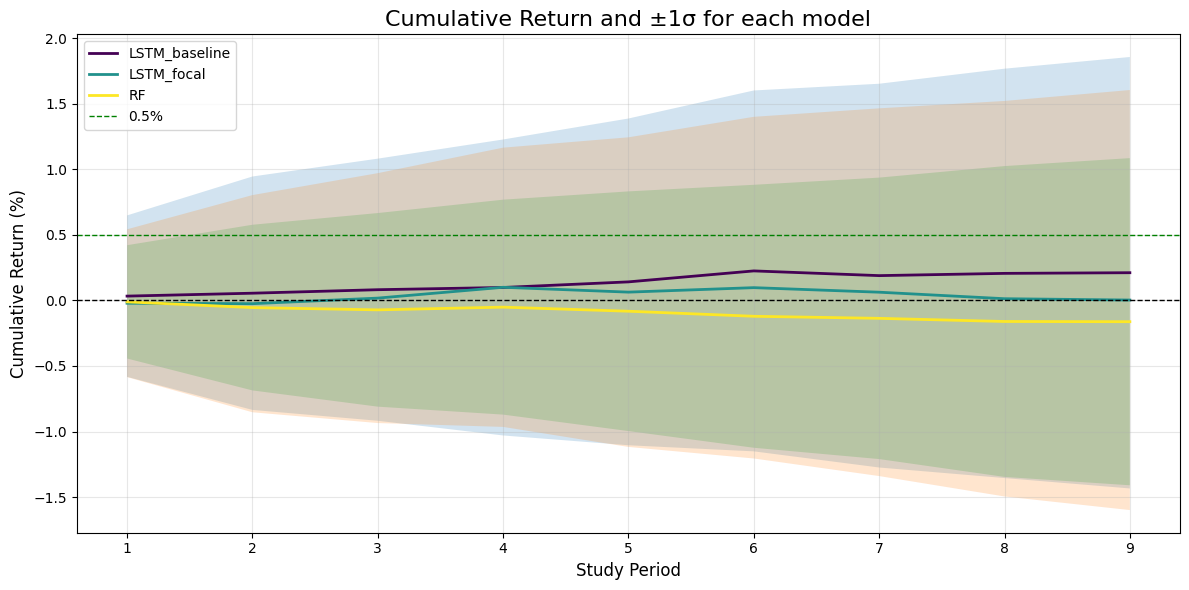

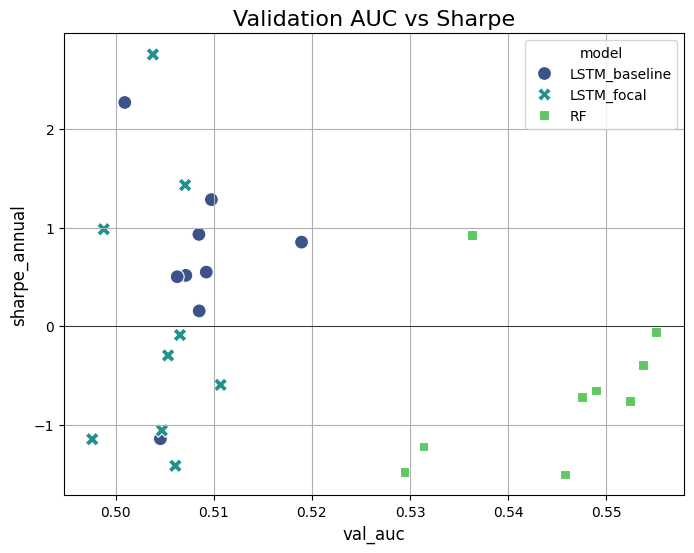

In [29]:
# 1) Carico i risultati aggregati
df = pd.read_csv("nasdaq100_lstm_vs_rf.csv")
df = df.iloc[:-3]

# Assicuriamoci che study_id sia ordinato
df = df.sort_values("study_id")

models = ["LSTM_baseline","LSTM_focal","RF"]
studies = df.study_id.unique()

viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

# 2) Grouped Bar Chart (2x3 subplot)
metrics = [
    ("mean_return_%", "Mean Ret %"),
    ("std_return_%",  "Std Ret %"),
    ("trade_acc",     "Trade Acc"),
    ("sharpe_annual", "Sharpe"),
    ("val_auc",       "Val AUC"),
    ("val_acc",       "Val Acc")
]

fig, axes = plt.subplots(2, 3, figsize=(18,10), sharex=True)
for (col, title), ax in zip(metrics, axes.flatten()):
    # pivot per avere colonne = modelli, indice = study_id
    pivot = df.pivot(index="study_id", columns="model", values=col).loc[studies, models]
    pivot.plot(kind="bar", ax=ax, width=0.8, color=viridis_colors)
    ax.set_title(title)
    ax.set_xlabel("Study Period")
    if col in ("mean_return_%","std_return_%"):
        ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2f}%")
    ax.legend(models)
plt.tight_layout()
plt.show()

# 3) Ritorno medio cumulato
fig, ax = plt.subplots(figsize=(12,6))

for m , color in zip(models, viridis_colors):
    sub = df[df.model==m].sort_values("study_id")
    # ritorno medio giornaliero in forma decimale
    r  = sub["mean_return_%"].values / 100
    # std giornaliera in decimale
    s  = sub["std_return_%"].values  / 100

    # ritorno cumulato per periodi (assumiamo periodi indipendenti)
    cum_ret = (1 + r).cumprod() - 1

    # errore cumulato: somma delle varianze
    cum_std = np.sqrt( np.cumsum(s**2) )

    ax.plot(studies,
            cum_ret * 100,
            label=m,
            linewidth=2,
            color=color)
    ax.fill_between(studies,
                    (cum_ret - cum_std)*100,
                    (cum_ret + cum_std)*100,
                    alpha=0.2)

# linee orizzontali di riferimento
ax.axhline(0,   color='black', linestyle='--', linewidth=1)
ax.axhline(0.5, color='green', linestyle='--', linewidth=1, label='0.5%')

ax.set_title("Cumulative Return and ±1σ for each model", fontsize=16)
ax.set_xlabel("Study Period", fontsize=12)
ax.set_ylabel("Cumulative Return (%)", fontsize=12)
ax.set_xticks(studies)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) SCATTER PLOT validation AUC vs Sharpe out‐of‐sample
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="val_auc", y="sharpe_annual",
    hue="model", style="model",
    palette="viridis", s=100,
)
plt.axhline(0, color='k', linewidth=0.5)
plt.title("Validation AUC vs Sharpe")
plt.grid(True)
plt.show()

### Multivariate GRU

- **Regime-awareness**
  In addition to univariate returns, we have introduced three _cross-sectional regime_ features calculated daily across the entire ticker universe:
  - **Volatility**: cross-sectional standard deviation of returns
  - **Skewness**: cross-sectional asymmetry
  - **Kurtosis**: cross-sectional ‘tail’
- **Multivariate input**
  Each lookback sequence = 240 days now has the shape **(240, 4)**:
- **GRU vs LSTM**
  Gated Recurrent Units (GRUs) are ‘leaner’ recurrent models and often converge more quickly, which is advantageous when resources and time are limited (they combine short- and long-term memory into a single hidden state).

  They consist of two gates:

  1. Update Gate:  Decides how much memory from the past should be retained for the future. This prevents important details from being forgotten at the start of a long sentence.

  2. Reset Gate: Decides how much memory from the past to discard when new information arrives. This allows the network to ‘turn the page’ and not be distracted by old contexts.

In [27]:
# ============================================================
# Parametri globali
# ============================================================
LOOKBACK    = 240
TRAIN_DAYS  = 750
TRADE_DAYS  = 250
ROLL_STEP   = 150
BATCH_SIZE  = 512
EPOCHS_MAX  = 50

# Numero massimo di study periods
MAX_PERIODS = 10

# =============================================================================
# Funzione che calcola le metriche long-short
# =============================================================================
def compute_long_short_metrics(y_pred_proba, returns_raw, k=10):
    n_tk   = returns_raw.shape[1]
    n_days = len(y_pred_proba) // n_tk
    y_pred = y_pred_proba.reshape(n_days, n_tk)
    ret    = returns_raw[-n_days:,:]
    port   = []
    for d in range(n_days):
        probs = y_pred[d]
        if len(probs) >= 2*k:
            idx = np.argsort(-probs)
            long_r  = ret[d, idx[:k]].mean()
            short_r = ret[d, idx[-k:]].mean()
            port.append((long_r - short_r)/2)
    port      = np.array(port)
    mean_ret  = port.mean()*100
    std_ret   = port.std()*100
    sharpe    = ((mean_ret/100)/(std_ret/100))*np.sqrt(252) if std_ret>0 else np.nan
    return mean_ret, std_ret, sharpe

# =============================================================================
# Costruisce sequenze multivariate (ritorno + vol + skew + kurt)
# =============================================================================
def create_sequences_multi(returns_df, cross_df, labels_df, lookback=LOOKBACK):
    X, y = [], []
    dates = returns_df.index
    tik   = returns_df.columns
    for t in range(lookback, len(dates)):
        window_ret = returns_df.iloc[t-lookback:t]
        window_vol = cross_df['vol'].iloc[t-lookback:t].values
        window_sk  = cross_df['skew'].iloc[t-lookback:t].values
        window_ku  = cross_df['kurt'].iloc[t-lookback:t].values
        lbl_row    = labels_df.iloc[t]
        # per ogni ticker che non abbia NaN nella finestra
        valid = window_ret.columns[window_ret.notnull().all(axis=0)]
        for tk in valid:
            seq_ret = window_ret[tk].values
            # stack delle 4 feature
            seq = np.stack([seq_ret, window_vol, window_sk, window_ku], axis=1)
            X.append(seq)
            y.append(lbl_row[tk])
    return np.array(X), np.array(y)

# =============================================================================
# Costruttore del modello GRU multivariate
# =============================================================================
def build_gru():
    m = Sequential([
        # primo layer GRU: mantiene le sequenze per il layer successivo
        GRU(32, return_sequences=True, dropout=0.1, input_shape=(LOOKBACK,4)),
        # secondo layer GRU: aggrega la sequenza in un vettore di stato
        GRU(16, dropout=0.1),
        # output binario
        Dense(1, activation='sigmoid')
    ])
    m.compile(loss='binary_crossentropy',
              optimizer=Adam(1e-3),
              metrics=['accuracy'])
    return m

# =============================================================================
# Main loop sui study periods
# =============================================================================
all_results = []
for i, sp in enumerate(study_periods):
    if i >= MAX_PERIODS:
        break
    
    # riproducibilità
    seed = 1234 + sp['study_id']
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Estrai block train+trade
    mask  = (returns.index >= sp['train_start_date']) & (returns.index <= sp['trade_end_date'])
    block = returns.loc[mask].copy()

    # Filtra ticker con dati completi sul blocco intero
    block = block.dropna(axis=1, how='any')
    n_tk  = block.shape[1]
    if n_tk < 30:
        continue

    # Costruisci labels shiftate
    median_daily = block.median(axis=1)
    labels_blk   = (block >= median_daily.values.reshape(-1,1))\
                    .astype(int).shift(-1).dropna()
    block        = block.loc[labels_blk.index]
    returns_raw  = block.values

    # Calcola feature cross-sectional
    cross = pd.DataFrame(index=block.index)
    cross['vol']  = block.std(axis=1)
    cross['skew'] = block.skew(axis=1)
    cross['kurt'] = block.kurtosis(axis=1)

    # Standardizzazione FEATURE-BY-FEATURE
    train_mask       = block.index <= sp['train_end_date']
    # ritorni per ticker
    mu_ret           = block[train_mask].mean(axis=0)
    sigma_ret        = block[train_mask].std(axis=0).replace(0,1)
    block_std        = (block - mu_ret) / sigma_ret
    # cross-features globali
    mu_vol, mu_sk, mu_ku = cross.loc[train_mask].mean()
    sd_vol, sd_sk, sd_ku = cross.loc[train_mask].std().replace(0,1)
    cross_std = cross.copy()
    cross_std['vol']  = (cross['vol']  - mu_vol) / sd_vol
    cross_std['skew'] = (cross['skew'] - mu_sk)  / sd_sk
    cross_std['kurt'] = (cross['kurt'] - mu_ku)  / sd_ku

    # Genera sequenze multivariate
    X_all, y_all = create_sequences_multi(block_std, cross_std, labels_blk)
    # split train / trade
    n_train_seq = n_tk * (TRAIN_DAYS - LOOKBACK + 1)
    X_train_all = X_all[:n_train_seq]
    y_train_all = y_all[:n_train_seq]
    X_trade     = X_all[n_train_seq:]
    y_trade     = y_all[n_train_seq:]
    n_trade_seq = len(X_trade)

    # split 80/20 stratificato
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.20, random_state=seed, stratify=y_train_all
    )

    # build & fit GRU
    model = build_gru()
    es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_val,y_val),
        epochs=EPOCHS_MAX, batch_size=BATCH_SIZE,
        callbacks=[es], verbose=0
    )

    # metriche in-sample
    y_val_pred = model.predict(X_val, verbose=0).ravel()
    val_acc    = ( (y_val_pred>=0.5).astype(int) == y_val ).mean()
    val_auc    = roc_auc_score(y_val, y_val_pred)
    # metriche di trading
    y_tr_pred  = model.predict(X_trade, verbose=0).ravel()
    trade_acc  = ( (y_tr_pred>=0.5).astype(int) == y_trade ).mean()
    mean_ret, std_ret, sharpe = compute_long_short_metrics(y_tr_pred, returns_raw, k=10)

    # stampa riepilogo
    print(f"Study {sp['study_id']} | tickers={n_tk} | "
          f"val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | "
          f"trade_acc={trade_acc:.4f} | mean_ret={mean_ret:.3f}% | "
          f"std_ret={std_ret:.3f}% | sharpe={sharpe:.3f}")

    # salva risultati
    all_results.append({
        'study_id'     : sp['study_id'],
        'model'        : 'GRU_multivar',
        'n_tickers'    : n_tk,
        'n_train_seq'  : len(X_tr),
        'n_val_seq'    : len(X_val),
        'n_trade_seq'  : n_trade_seq,
        'val_acc'      : val_acc,
        'val_auc'      : val_auc,
        'trade_acc'    : trade_acc,
        'mean_return_%': mean_ret,
        'std_return_%' : std_ret,
        'sharpe_annual': sharpe
    })

# Salva risultati in CSV
pd.DataFrame(all_results).to_csv("nasdaq100_gru_multivar.csv", index=False)
print("Pipeline GRU multivariate completata, risultati in nasdaq100_gru_multivar.csv")

Study 1 | tickers=139 | val_acc=0.5055 | val_auc=0.5057 | trade_acc=0.5039 | mean_ret=-0.042% | std_ret=0.604% | sharpe=-1.092
Study 2 | tickers=141 | val_acc=0.5084 | val_auc=0.5100 | trade_acc=0.5051 | mean_ret=0.044% | std_ret=0.620% | sharpe=1.132
Study 3 | tickers=144 | val_acc=0.4977 | val_auc=0.4959 | trade_acc=0.4970 | mean_ret=-0.016% | std_ret=0.422% | sharpe=-0.590
Study 4 | tickers=147 | val_acc=0.5015 | val_auc=0.4987 | trade_acc=0.5012 | mean_ret=0.034% | std_ret=0.473% | sharpe=1.149
Study 5 | tickers=148 | val_acc=0.4988 | val_auc=0.4993 | trade_acc=0.5022 | mean_ret=0.053% | std_ret=0.527% | sharpe=1.612
Study 6 | tickers=156 | val_acc=0.5040 | val_auc=0.5005 | trade_acc=0.5030 | mean_ret=0.021% | std_ret=0.576% | sharpe=0.569
Study 7 | tickers=159 | val_acc=0.5031 | val_auc=0.5066 | trade_acc=0.5017 | mean_ret=-0.003% | std_ret=0.523% | sharpe=-0.097
Study 8 | tickers=161 | val_acc=0.5015 | val_auc=0.4995 | trade_acc=0.5034 | mean_ret=0.011% | std_ret=0.556% | sharpe=

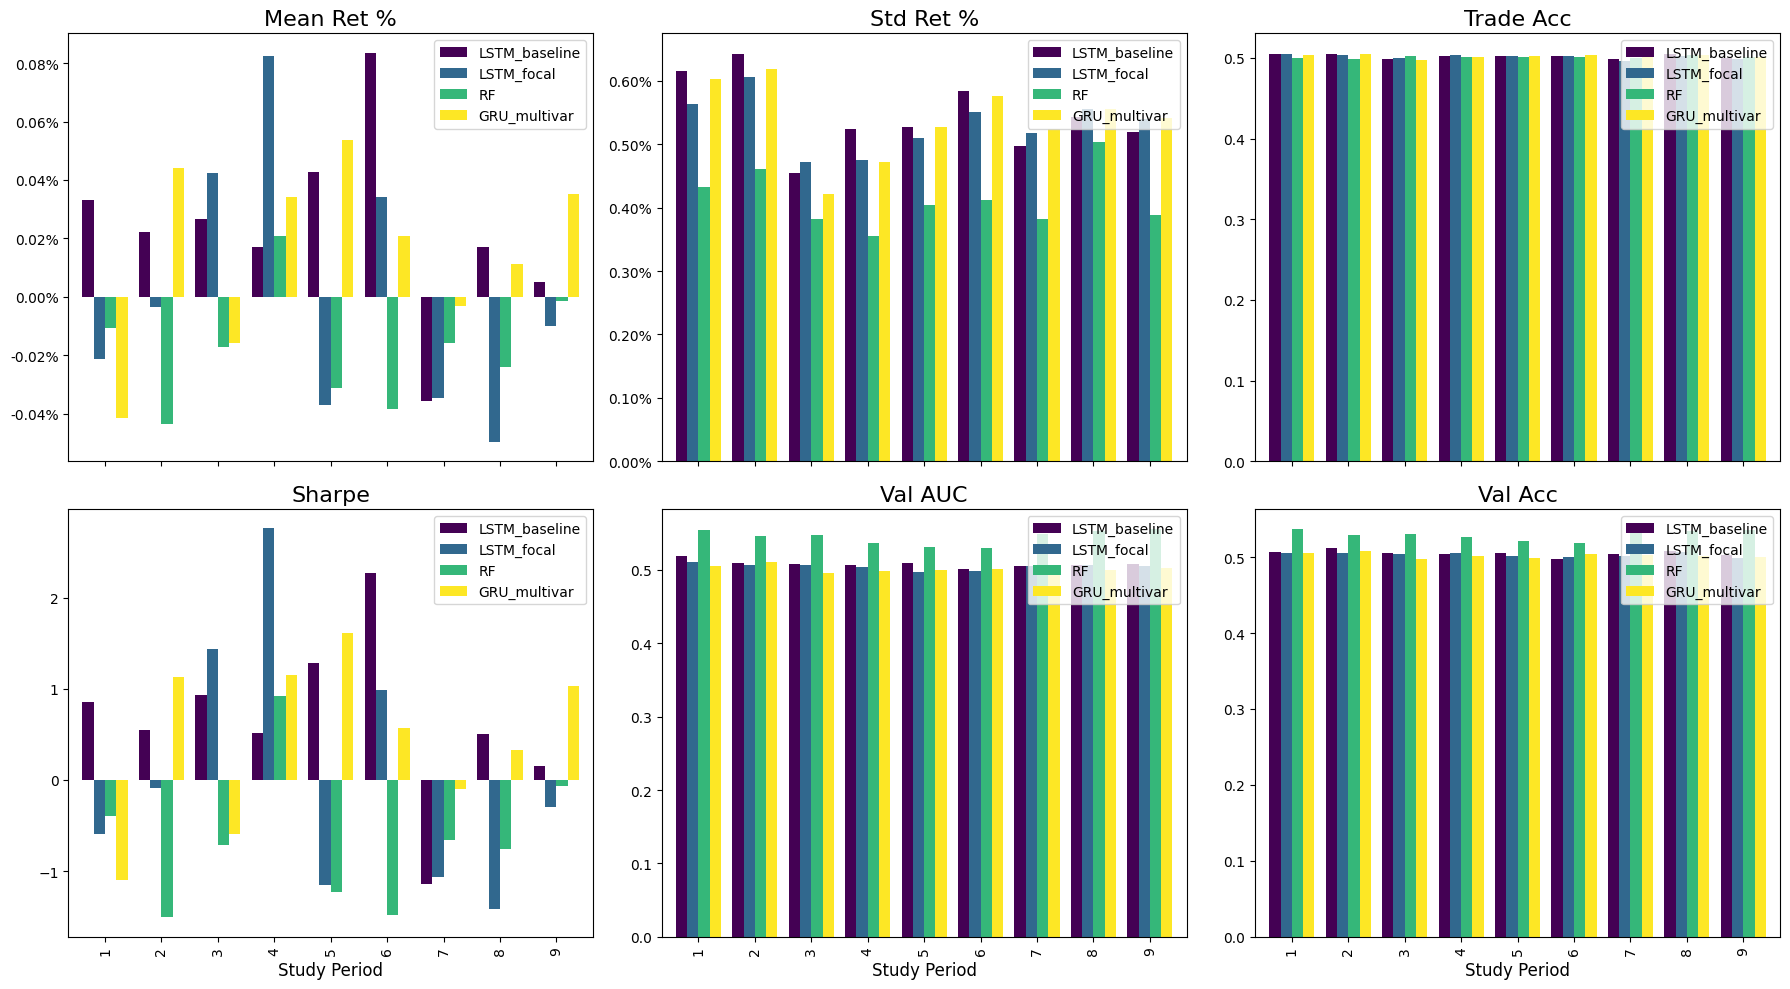

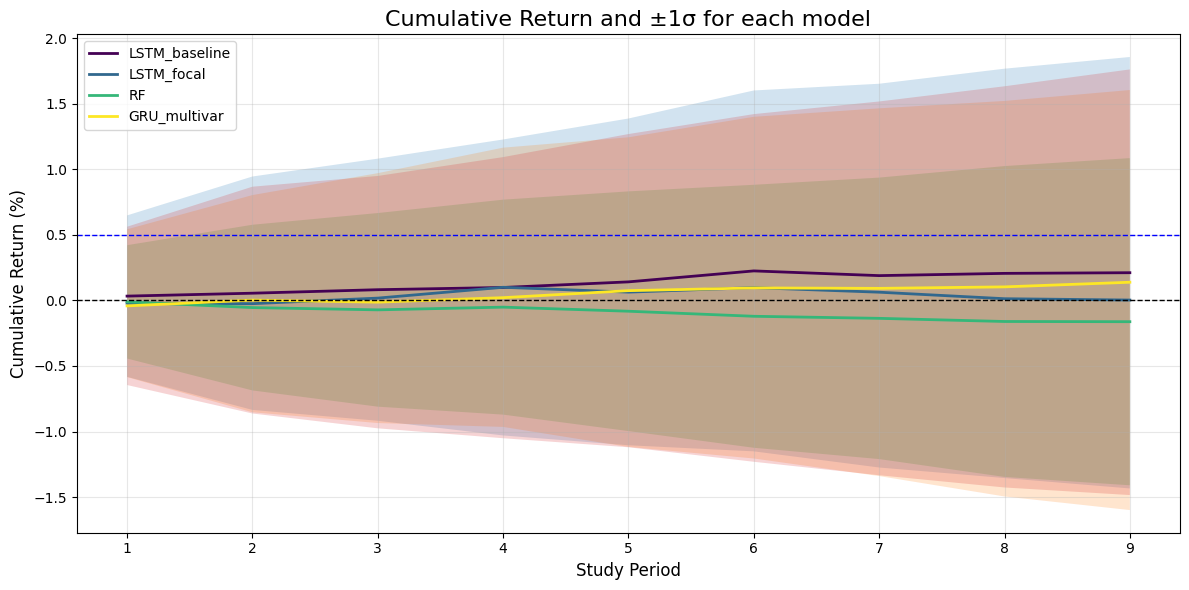

In [30]:
# 1) Carico i risultati aggregati
df = pd.read_csv("nasdaq100_lstm_vs_rf.csv")
df = df.iloc[:-3]

df_gru = pd.read_csv("nasdaq100_gru_multivar.csv")
df_gru = df_gru.iloc[:-1]  

# Concateno i due dataframe
df_concat = pd.concat([df, df_gru], ignore_index=True)

# Assicuriamoci che study_id sia ordinato
df_concat = df_concat.sort_values("study_id")

models = ["LSTM_baseline","LSTM_focal","RF", "GRU_multivar"]
studies = df_concat.study_id.unique()

viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

# 2) Grouped Bar Chart (2x3 subplot)
metrics = [
    ("mean_return_%", "Mean Ret %"),
    ("std_return_%",  "Std Ret %"),
    ("trade_acc",     "Trade Acc"),
    ("sharpe_annual", "Sharpe"),
    ("val_auc",       "Val AUC"),
    ("val_acc",       "Val Acc")
]

fig, axes = plt.subplots(2, 3, figsize=(18,10), sharex=True)
for (col, title), ax in zip(metrics, axes.flatten()):
    # pivot per avere colonne = modelli, indice = study_id
    pivot = df_concat.pivot(index="study_id", columns="model", values=col).loc[studies, models]
    pivot.plot(kind="bar", ax=ax, width=0.8, color=viridis_colors)
    ax.set_title(title)
    ax.set_xlabel("Study Period")
    if col in ("mean_return_%","std_return_%"):
        ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2f}%")
    ax.legend(models)
plt.tight_layout()
plt.show()

# 3) Calcolo del ritorno composto e deviazione standard cumulativa
fig, ax = plt.subplots(figsize=(12,6))

for m, color in zip(models, viridis_colors):
    sub = df_concat[df_concat.model==m].sort_values("study_id")
    # ritorno medio giornaliero in forma decimale
    r  = sub["mean_return_%"].values / 100
    # std giornaliera in decimale
    s  = sub["std_return_%"].values  / 100

    # ritorno cumulato per periodi (assumiamo periodi indipendenti)
    cum_ret = (1 + r).cumprod() - 1

    # errore cumulato: somma delle varianze
    cum_std = np.sqrt( np.cumsum(s**2) )

    ax.plot(studies,
            cum_ret * 100,
            label=m,
            linewidth=2,
            color=color)
    ax.fill_between(studies,
                    (cum_ret - cum_std)*100,
                    (cum_ret + cum_std)*100,
                    alpha=0.2)

# linee orizzontali di riferimento
ax.axhline(0,   color='black', linestyle='--', linewidth=1)
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1)

ax.set_title("Cumulative Return and ±1σ for each model", fontsize=16)
ax.set_xlabel("Study Period", fontsize=12)
ax.set_ylabel("Cumulative Return (%)", fontsize=12)
ax.set_xticks(studies)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


No single model dominates across all periods:

- The LSTM-baseline is often stable and capable of producing positive Sharpe ratios in several study periods (e.g. 1, 3, 4, 6).

- LSTM-focal excels in phase 4 (Sharpe ≈ 2.8) but struggles during severe crises (1, 2, 5, 7).

- RandomForest performs very well in-sample (val_acc ≈ 0.53–0.55) but then tends to yield negative Sharpe ratios in trading, a sign of memory-free overfitting.

- GRU_multivar (return+vol+skew+kurt) delivers mixed performance: good in some periods (2, 4, 5, 9, 10) but mediocre or negative in others (1, 3, 7).

Trade_acc is consistently around 50–50 per cent ‘lucky’ and does not make much of a difference, whilst it is the quality of the ‘predicted winning’ days (long_ret vs short_ret) that makes the difference to mean_return and the Sharpe ratio.

The LSTM-baseline remains the most consistent and stable choice over the long term, with positive Sharpe ratios in half of the blocks and drawdowns managed fairly well.

Focal loss introduces a more ‘conservative’ behaviour (slightly lower std_ret) but does not systematically improve either the val_auc or the overall Sharpe ratio.

The addition of cross-sectional features (GRU_multivar) has enriched the regime signal, but at the cost of greater complexity and without a clear average advantage.


### Final comparison: LSTM_baseline vs multivariate LSTM (1-layer and 2-layer)

We compared three LSTM network configurations, all trained using the same rolling protocol:

1. **LSTM_baseline**
   – Input: univariate return series only
   – Architecture: 1-layer LSTM(25) + Dense (1)

2. **LSTM_multivar_1layer**
   – Input: 4 multivariate features (return, vol_x, skew_x, kurt_x)
   – Architecture: 1-layer LSTM(25) + Dense(1)

3. **LSTM_multivar_2layer**
   – Same 4-feature input
   – Architecture: 2 LSTM layers (25 → 12) + Dense(1)

In [41]:
# ============================================================
# Parametri globali
# ============================================================
LOOKBACK    = 240
TRAIN_DAYS  = 750
TRADE_DAYS  = 250
ROLL_STEP   = 150
BATCH_SIZE  = 512
EPOCHS_MAX  = 50

# Numero massimo di study periods
MAX_PERIODS = 9

# =============================================================================
# Funzione che calcola le metriche long-short
# =============================================================================
def compute_long_short_metrics(y_pred_proba, returns_raw, k=10):
    n_tk   = returns_raw.shape[1]
    n_days = len(y_pred_proba) // n_tk
    y_pred = y_pred_proba.reshape(n_days, n_tk)
    ret    = returns_raw[-n_days:,:]
    port   = []
    for d in range(n_days):
        probs = y_pred[d]
        if len(probs) >= 2*k:
            idx = np.argsort(-probs)
            long_r  = ret[d, idx[:k]].mean()
            short_r = ret[d, idx[-k:]].mean()
            port.append((long_r - short_r)/2)
    port      = np.array(port)
    mean_ret  = port.mean()*100
    std_ret   = port.std()*100
    sharpe    = ((mean_ret/100)/(std_ret/100))*np.sqrt(252) if std_ret>0 else np.nan
    return mean_ret, std_ret, sharpe

# =============================================================================
# Costruisce sequenze multivariate (ritorno + vol + skew + kurt)
# =============================================================================
def create_sequences_multi(returns_df, cross_df, labels_df, lookback=LOOKBACK):
    X, y = [], []
    dates = returns_df.index
    tik   = returns_df.columns
    for t in range(lookback, len(dates)):
        window_ret = returns_df.iloc[t-lookback:t]
        window_vol = cross_df['vol'].iloc[t-lookback:t].values
        window_sk  = cross_df['skew'].iloc[t-lookback:t].values
        window_ku  = cross_df['kurt'].iloc[t-lookback:t].values
        lbl_row    = labels_df.iloc[t]
        # per ogni ticker che non abbia NaN nella finestra
        valid = window_ret.columns[window_ret.notnull().all(axis=0)]
        for tk in valid:
            seq_ret = window_ret[tk].values
            # stack delle 4 feature
            seq = np.stack([seq_ret, window_vol, window_sk, window_ku], axis=1)
            X.append(seq)
            y.append(lbl_row[tk])
    return np.array(X), np.array(y)

# =============================================================================
# Costruttore del modello LSTM multivariate - 2 layer
# =============================================================================
def build_lstm_multivar_2layer(lookback=240, n_feats=4):
    model = Sequential([
        # ora input_shape = (tempo, numero di feature) (240, 4)
        # il primo lstm ritorna T=240 timesteps, ognuno con 25 features (hidden units)
        LSTM(25, input_shape=(lookback, n_feats), dropout=0.1, recurrent_dropout=0.1,
             return_sequences=True),
        # provo a aggiungere un layer per aumentare capacità sequenziale
        # magari cattura meglio le dinamiche multivariate
        LSTM(12, dropout=0.1, recurrent_dropout=0.1),   
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer=RMSprop(),
        metrics=['accuracy']
    )
    return model

# =============================================================================
# 2) Costruttore LSTM multivar 1‐layer (baseline esteso a 4 feature)
# =============================================================================
def build_lstm_multivar_1layer(lookback=240, n_feats=4):
    model = Sequential([
        LSTM(25, input_shape=(lookback,n_feats),
             dropout=0.1, recurrent_dropout=0.1),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy',
                  optimizer=RMSprop(),
                  metrics=['accuracy'])
    return model

# =============================================================================
# Main loop sui study periods
# =============================================================================
all_results = []

for i, sp in enumerate(study_periods):
    if i >= MAX_PERIODS:
        break

    # riproducibilità
    seed = 1234 + sp['study_id']
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Estrai block train+trade e filtra ticker completi
    mask  = (returns.index >= sp['train_start_date']) & (returns.index <= sp['trade_end_date'])
    block = returns.loc[mask].dropna(axis=1, how='any')
    n_tk  = block.shape[1]
    if n_tk < 30: 
        continue

    # Labels shiftate
    median_daily = block.median(axis=1)
    labels_blk   = (block >= median_daily.values.reshape(-1,1)).astype(int)\
                     .shift(-1).dropna()
    block        = block.loc[labels_blk.index]
    returns_raw  = block.values

    # Feature cross‐sectional
    cross = pd.DataFrame(index=block.index)
    cross['vol']  = block.std(axis=1)
    cross['skew'] = block.skew(axis=1)
    cross['kurt'] = block.kurtosis(axis=1)

    # Standardizzazione per ticker e per feature cross‐sec
    train_mask        = block.index <= sp['train_end_date']
    mu_ret            = block[train_mask].mean(axis=0)
    sigma_ret         = block[train_mask].std(axis=0).replace(0,1)
    block_std         = (block - mu_ret) / sigma_ret
    mu_vol, mu_sk, mu_ku = cross.loc[train_mask].mean()
    sd_vol, sd_sk, sd_ku = cross.loc[train_mask].std().replace(0,1)
    cross_std = cross.copy()
    cross_std['vol']  = (cross['vol']  - mu_vol) / sd_vol
    cross_std['skew'] = (cross['skew'] - mu_sk)  / sd_sk
    cross_std['kurt'] = (cross['kurt'] - mu_ku)  / sd_ku

    # Crea sequenze multivariate
    X_all, y_all = create_sequences_multi(block_std, cross_std, labels_blk)
    # split train / trade
    n_train_seq   = n_tk * (TRAIN_DAYS - LOOKBACK + 1)
    X_train_all   = X_all[:n_train_seq]
    y_train_all   = y_all[:n_train_seq]
    X_trade       = X_all[n_train_seq:]
    y_trade       = y_all[n_train_seq:]
    n_trade_seq   = len(X_trade)

    # split train/val stratificato
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_all, y_train_all,
        test_size=0.20, random_state=seed, stratify=y_train_all
    )

    # Lista di (nome, builder) per i due modelli
    builders = [
        ('LSTM_2layer', build_lstm_multivar_2layer),
        ('LSTM_1layer', build_lstm_multivar_1layer)
    ]

    for name, builder in builders:
        model = builder(lookback=LOOKBACK, n_feats=4)
        es = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=0)
        model.fit(X_tr, y_tr,
                  validation_data=(X_val,y_val),
                  epochs=EPOCHS_MAX, batch_size=BATCH_SIZE,
                  callbacks=[es], verbose=0)

        # metriche in-sample
        y_val_pred = model.predict(X_val, verbose=0).ravel()
        val_acc    = ((y_val_pred>=0.5).astype(int)==y_val).mean()
        val_auc    = roc_auc_score(y_val, y_val_pred)
        # metriche di trading
        y_tr_pred  = model.predict(X_trade, verbose=0).ravel()
        trade_acc  = ((y_tr_pred>=0.5).astype(int)==y_trade).mean()
        mean_ret, std_ret, sharpe = compute_long_short_metrics(y_tr_pred, returns_raw, k=10)

        # Stampa e memorizza
        print(f"Study {sp['study_id']} | Model={name} | tickers={n_tk} | "
              f"val_acc={val_acc:.4f} | val_auc={val_auc:.4f} | "
              f"trade_acc={trade_acc:.4f} | mean_ret={mean_ret:.3f}% | "
              f"std_ret={std_ret:.3f}% | sharpe={sharpe:.3f}")

        all_results.append({
            'study_id'     : sp['study_id'],
            'model'        : name,
            'n_tickers'    : n_tk,
            'n_train_seq'  : len(X_tr),
            'n_val_seq'    : len(X_val),
            'n_trade_seq'  : n_trade_seq,
            'val_acc'      : val_acc,
            'val_auc'      : val_auc,
            'trade_acc'    : trade_acc,
            'mean_return_%': mean_ret,
            'std_return_%' : std_ret,
            'sharpe_annual': sharpe
        })

# Salva risultati
pd.DataFrame(all_results).to_csv("nasdaq100_lstm_multivar_compare.csv", index=False)
print("Done: results in nasdaq100_lstm_multivar_compare.csv")

Study 1 | Model=LSTM_2layer | tickers=139 | val_acc=0.4985 | val_auc=0.4971 | trade_acc=0.5033 | mean_ret=-0.004% | std_ret=0.667% | sharpe=-0.100
Study 1 | Model=LSTM_1layer | tickers=139 | val_acc=0.5053 | val_auc=0.5092 | trade_acc=0.5011 | mean_ret=-0.017% | std_ret=0.656% | sharpe=-0.414
Study 2 | Model=LSTM_2layer | tickers=141 | val_acc=0.5039 | val_auc=0.5033 | trade_acc=0.5029 | mean_ret=-0.037% | std_ret=0.576% | sharpe=-1.015
Study 2 | Model=LSTM_1layer | tickers=141 | val_acc=0.5007 | val_auc=0.5038 | trade_acc=0.5036 | mean_ret=0.059% | std_ret=0.599% | sharpe=1.552
Study 3 | Model=LSTM_2layer | tickers=144 | val_acc=0.4966 | val_auc=0.4945 | trade_acc=0.4999 | mean_ret=-0.046% | std_ret=0.461% | sharpe=-1.580
Study 3 | Model=LSTM_1layer | tickers=144 | val_acc=0.4966 | val_auc=0.4945 | trade_acc=0.4950 | mean_ret=-0.044% | std_ret=0.449% | sharpe=-1.547
Study 4 | Model=LSTM_2layer | tickers=147 | val_acc=0.5029 | val_auc=0.4974 | trade_acc=0.5032 | mean_ret=-0.011% | std_

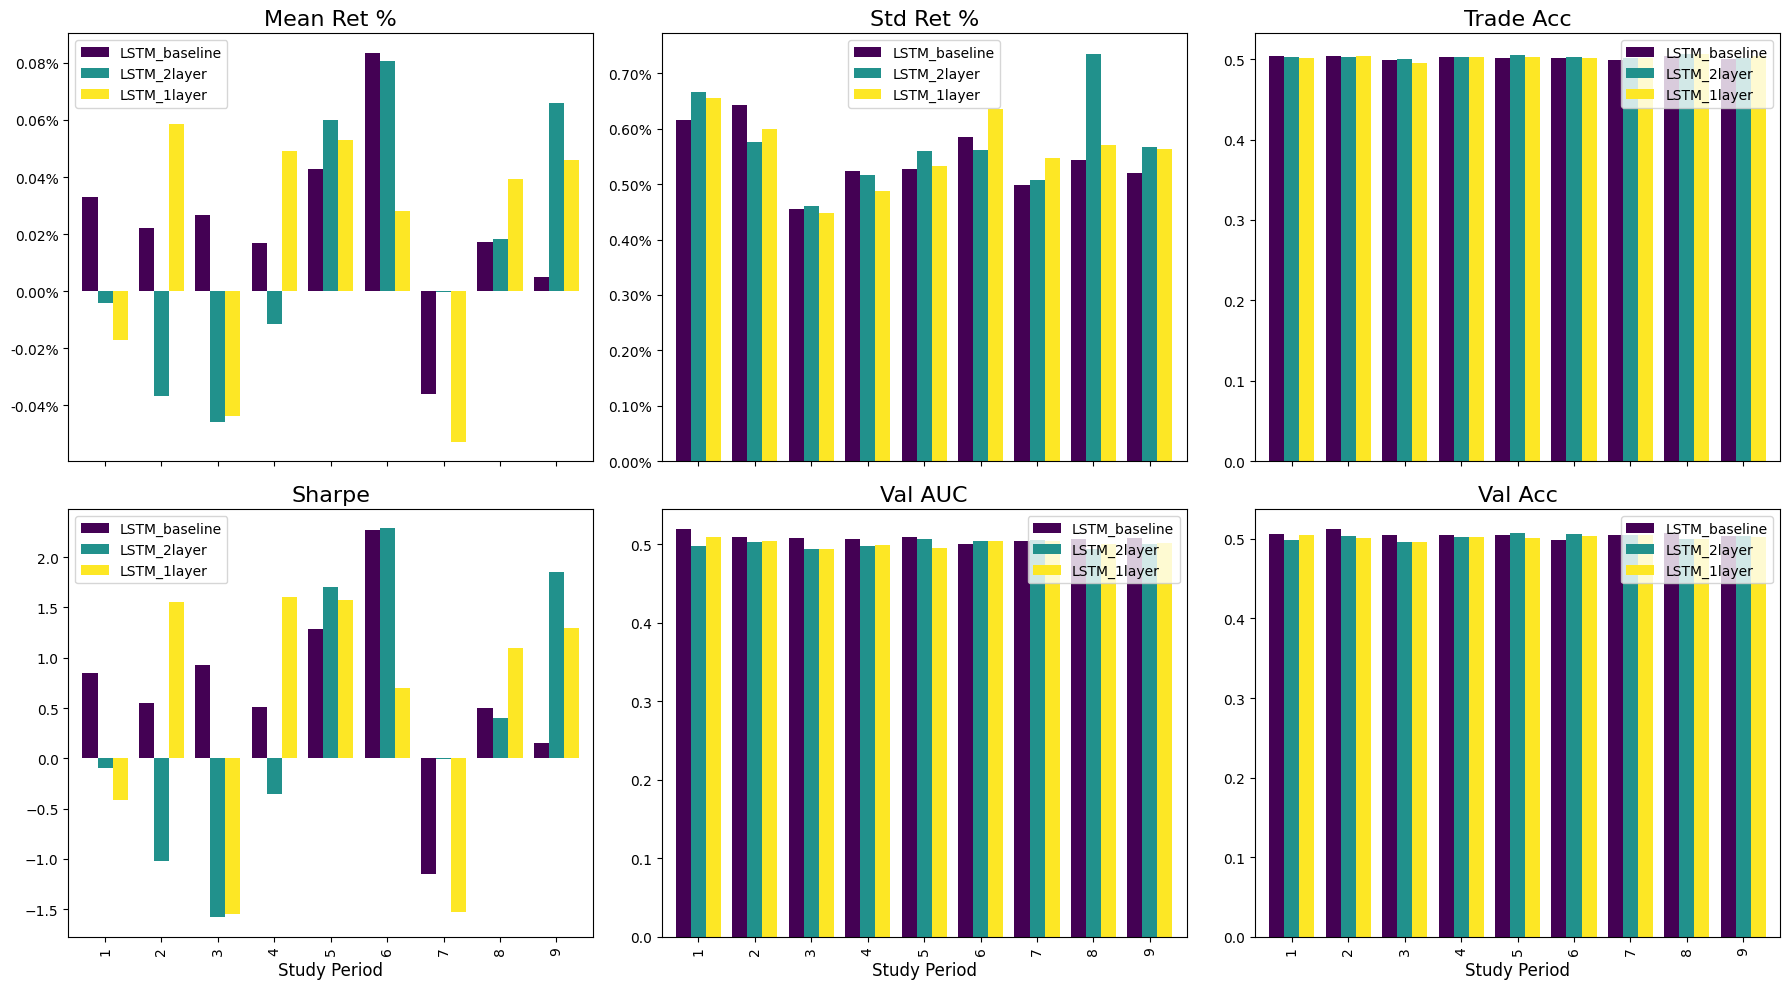

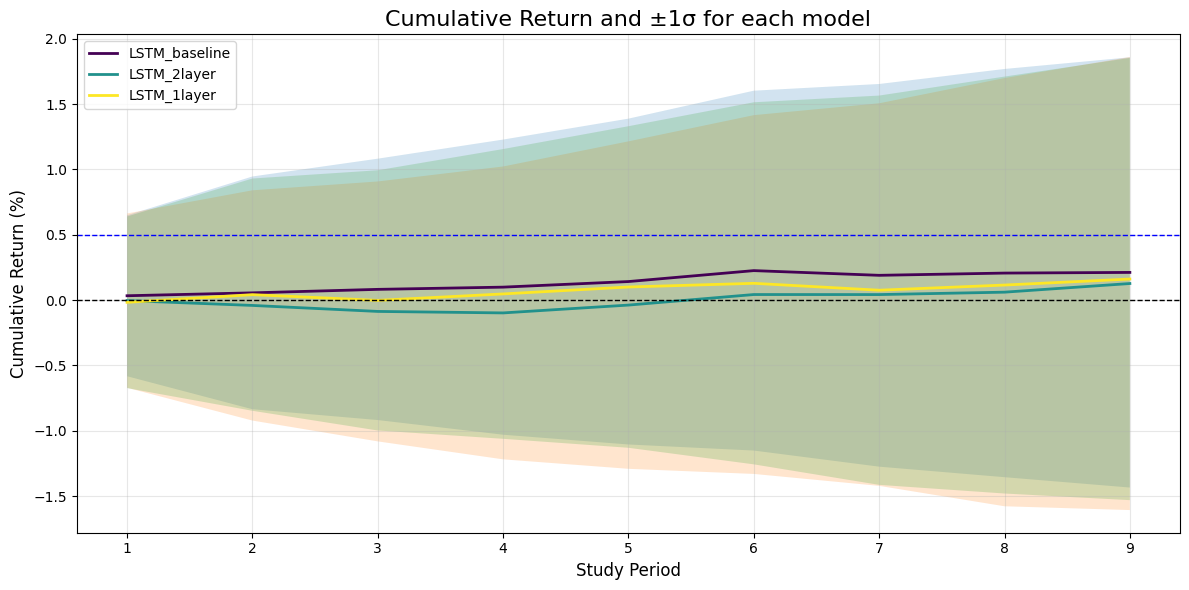

In [31]:
# Carico i risultati aggregati nasdaq100_lstm_vs_rf.csv
# salvo solo i valory per model=LSTMbaseline

df = pd.read_csv("nasdaq100_lstm_vs_rf.csv")
df = df.iloc[:-3]
df = df[df['model'] == 'LSTM_baseline']

df_multivar = pd.read_csv("nasdaq100_lstm_multivar_compare.csv")

df_concat = pd.concat([df, df_multivar], ignore_index=True)

# Assicuriamoci che study_id sia ordinato
df_concat = df_concat.sort_values("study_id")

models = ["LSTM_baseline","LSTM_2layer","LSTM_1layer"]
studies = df_concat.study_id.unique()

viridis_colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

# 1) Grouped Bar Chart (2x3 subplot)
metrics = [
    ("mean_return_%", "Mean Ret %"),
    ("std_return_%",  "Std Ret %"),
    ("trade_acc",     "Trade Acc"),
    ("sharpe_annual", "Sharpe"),
    ("val_auc",       "Val AUC"),
    ("val_acc",       "Val Acc")
]

fig, axes = plt.subplots(2, 3, figsize=(18,10), sharex=True)
for (col, title), ax in zip(metrics, axes.flatten()):
    # pivot per avere colonne = modelli, indice = study_id
    pivot = df_concat.pivot(index="study_id", columns="model", values=col).loc[studies, models]
    pivot.plot(kind="bar", ax=ax, width=0.8, color=viridis_colors)
    ax.set_title(title)
    ax.set_xlabel("Study Period")
    if col in ("mean_return_%","std_return_%"):
        ax.yaxis.set_major_formatter(lambda x, _: f"{x:.2f}%")
    ax.legend(models)
plt.tight_layout()
plt.show()


# 2) Cumulative Return and ±1σ 
fig, ax = plt.subplots(figsize=(12,6))

for m, color in zip(models, viridis_colors):
    sub = df_concat[df_concat.model==m].sort_values("study_id")
    # ritorno medio giornaliero in forma decimale
    r  = sub["mean_return_%"].values / 100
    # std giornaliera in decimale
    s  = sub["std_return_%"].values  / 100

    # ritorno cumulato per periodi (assumiamo periodi indipendenti)
    cum_ret = (1 + r).cumprod() - 1

    # errore cumulato: somma delle varianze
    cum_std = np.sqrt( np.cumsum(s**2) )

    ax.plot(studies,
            cum_ret * 100,
            label=m,
            linewidth=2,
            color=color)
    ax.fill_between(studies,
                    (cum_ret - cum_std)*100,
                    (cum_ret + cum_std)*100,
                    alpha=0.2)

# linee orizzontali di riferimento
ax.axhline(0,   color='black', linestyle='--', linewidth=1)
ax.axhline(0.5, color='blue', linestyle='--', linewidth=1)

ax.set_title("Cumulative Return and ±1σ for each model", fontsize=16)
ax.set_xlabel("Study Period", fontsize=12)
ax.set_ylabel("Cumulative Return (%)", fontsize=12)
ax.set_xticks(studies)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Observations

- **Mean Ret %** and **Sharpe**
  The LSTM_baseline model shows, on average, more consistent positive returns and higher Sharpe ratios in most of the nine studies.
  Multivariate models, particularly the 2-layer model, struggle to translate their greater complexity into additional returns, generating negative mean_ret and negative Sharpe ratios in many blocks.

- **Std Ret %**
  The introduction of volatility/skew/kurtosis features slightly increases the dispersion of returns (higher std_ret), but does not lead to compensatory gains.

- **Trade Acc, Val Acc, Val AUC**
  All three models achieve around 50–51% accuracy and an AUC of ~0.50 in validation, with no substantial improvements for the multivariate versions.

## Why we did not carry out a proper hyperparameter optimisation

In our initial workflow, we considered both:

- an exhaustive **grid search** on the main hyperparameters (units, dropout, batch size)
- a **Bayesian/Random Search** approach (Hyperopt)

However, we decided against this for two main reasons:

1. **Prohibitive computation time**
   - Each grid search, run on a personal laptop, took hours or days to cover just a few dozen combinations within a single study period.
   - With 8–10 rolling training/trading windows, the computational cost became unsustainable.

2. **Unjustifiable improvements**
   - The few adjustments resulted in changes in accuracy and the Sharpe ratio that were smaller than those observed simply by varying the study period.
    - With 8–10 rolling training/trading windows, the computational cost became unsustainable.

2. **Unjustifiable improvements**
   - The few tuning adjustments resulted in changes in accuracy and the Sharpe ratio that were smaller than those observed simply by varying the study period.
   - The improvement in metrics was often marginal and not reproducible, so it did not justify the long execution time.

Consequently, we switched to **fixed hyperparameters taken from the literature** (25-unit LSTM, dropout 0.1, batch size 512) and focused on quick comparisons between:
- Baseline LSTM vs LSTM + Focal Loss
- Univariate LSTM vs multivariate LSTM vs multivariate GRU

so as to maximise the **benefit-to-computational-cost ratio** without compromising the validity of our conclusions.

## Conclusions

- **Simplicity vs complexity**
  The univariate LSTM proves to be the most robust and stable solution, despite being the simplest.
- **Regime features**
  The cross-sectional features of volatility, skew and kurtosis did not yield a net improvement: a different way of incorporating them is likely required (e.g. attention, dedicated layer).
- **Level of complexity**
  Adding a second LSTM layer worsens the results, a sign of over-parameterisation given the scarcity of truly useful signal.

 **Future Improvements and Limitations**
 - Combine LSTM_baseline and LSTM_multivar into a lightweight ensemble;
 - Optimise the classification threshold to directly maximise the Sharpe ratio;
 - Experiment with attention layers or a specific cross-sectional pooling method.

 However, given the time constraints and complexity, the univariate LSTM_baseline model represents the _best trade-off_ between performance, stability and simplicity.

## Cross-period validation (Leave-One-Block-Out)

So far, we have divided the entire historical period into K ‘study periods’ (e.g. 9 blocks of 1,000 days each), and for each block we have:

1. Trained (train+val) on 750 days,
2. Tested out-of-sample on 250 days.

This gives us **K out-of-sample performance evaluations** (somewhat like a k-fold split), but it does not constitute true **cross-validation** because:

- We have retrained **hyperparameters** and models **separately** on each block,
- We have not ‘set aside’ a block to assess the robustness of a **fixed** model trained on the others.

### Possible Implementation: Leave-One-Block-Out CV

To estimate the model’s predictive ability ‘once’ (rather than custom-fitting it to each block), we can do the following:

1. For each block j = 1…K:
   a. **Train** on all periods _except_ j (each period provides its own 750 days of training and validation data).
   b. **Test** on the trading set (250 days) of block j.
2. Calculate the metrics (Sharpe ratio, mean return, trade accuracy, etc.) for each of the K test sets.
3. The mean and standard deviation of these K performance metrics constitute the true estimate of generalisation.

In this framework:

- The hyperparameters (number of units, dropout, batch_size, loss function, etc.) are **selected only once** (e.g. on a small subset or a priori from the literature).
- The final model remains **unchanged** throughout the K folds, and we measure its quality on **truly out-of-sample** data.

### Why it is important

- We avoid the risk of **overfitting on individual blocks** (we tune the model just once, not for each rolling window).
- We obtain a more robust and less optimistic estimate of future performance, because each ‘fold’ is an independent time block.
- If the average results and standard deviation are satisfactory, we know that a _unique-fit_ model will perform reasonably well on new data.

---

**In summary**: our pipeline is already a sort of ‘rolling backtest’, but to move from a model that **re-trains in every period** to a truly generalising _single_ model, we need a leave-one-block-out validation (or a TimeSeriesSplit) that gives us a single set of hyperparameters and a single performance metric across multiple blocks.